# Corpus-Level Statistical Analysis of All 3,000 SymbTr TXT v3.0 Files Together

This notebook performs a corpus-level statistical analysis by processing **all 3,000 symbolic TXT files together** rather than examining individual compositions separately. Each file is parsed to extract descriptive metadata and symbolic music information, from which a standardized set of statistical features is computed.

The extracted statistics are then combined into a unified corpus-level dataset, where each row represents a musical composition and each column corresponds to a statistical descriptor. This consolidated representation serves as the foundation for subsequent visualization, exploratory data analysis, dimensionality reduction, clustering, machine learning, and computational musicology studies.

## Importing the Required Libraries

This section imports the Python libraries required for corpus-level analysis of the SymbTr TXT collection. The imported modules support file-system navigation, regular-expression processing, frequency counting, numerical computation, and tabular data analysis throughout the notebook.

**Output.** This cell produces no visible output.

In [98]:
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd

## Defining the Dataset Location

Before analyzing the symbolic music collection, this notebook defines the location of the extracted dataset within the project's **interim data** directory.

The extracted TXT files serve as the primary data source for the analyses presented in this and the subsequent notebooks. Defining the dataset location consistently ensures that every notebook follows the same project structure, improving reproducibility and portability across different computing environments.

**Output.** This cell produces no visible output.

In [99]:
from pathlib import Path

# Define the project directories
project_root = Path.cwd().resolve().parents[1]

data_directory = project_root / "data"
interim_data_directory = data_directory / "interim"

# Define the location of the extracted dataset
extracted_directory = interim_data_directory

## Verifying the Dataset Directory

Before processing the corpus, it is important to verify that the dataset directory exists. This validation step confirms that the extracted files are accessible and ready for analysis.

**Output.** This cell reports whether the dataset directory has been successfully located.

In [100]:
# Verify that the extracted dataset directory exists
if extracted_directory.exists():
    print("✓ Extracted dataset directory found.")
else:
    print("✗ Extracted dataset directory not found.")

✓ Extracted dataset directory found.


## Locating the TXT Files

The SymbTr dataset contains **3,000** TXT files, each representing a symbolic music composition together with its metadata and musical event sequence.

This section locates all TXT files within the extracted dataset directory. The resulting file list serves as the primary input for the corpus-level statistical analyses performed throughout this notebook.

**Output.** This cell reports the total number of discovered TXT files.

In [101]:
# Define the TXT dataset directory
txt_directory = extracted_directory / "txt_v3"

# Locate all TXT files
txt_files = sorted(txt_directory.rglob("*.txt"))

print(f"Total TXT files: {len(txt_files):,}")

Total TXT files: 3,000


## Inspecting the Dataset Structure

Before performing the corpus-level statistical analysis, it is useful to inspect a small sample of the extracted TXT files. Displaying the relative paths of a few representative files provides a quick overview of the dataset organization and confirms that the symbolic music collection has been located correctly.

For readability, only the first ten TXT files are displayed.

**Output.** This cell displays the relative paths of the first ten TXT files.

In [102]:
# Display the first ten TXT files
for i, file in enumerate(txt_files[:10], start=1):
    print(f"{i:2d}. {file.relative_to(txt_directory)}")

 1. txt_v3\acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
 2. txt_v3\acem--ilahi--nimevsat--calabim_bir--haci_bayram_veli.txt
 3. txt_v3\acem--kupe--duyek--zulfunu--ahmet_avni_konuk.txt
 4. txt_v3\acem--selam--devrikebir--asik-i_ger--huseyin_fahreddin_dede.txt
 5. txt_v3\acem--seyir--sofyan----sefik_gurmeric.txt
 6. txt_v3\acem--seyir--sofyan--1--erol_bingol.txt
 7. txt_v3\acem--turku--duyek--ordunun_dereleri--ordu.txt
 8. txt_v3\acemasiran--agirsemai--senginsemai--ey_lebleri--dede_efendi.txt
 9. txt_v3\acemasiran--aranagme--agiraksak--1--.txt
10. txt_v3\acemasiran--aranagme--aksak--1--.txt


## Loading and Understanding a Representative TXT File

Before performing the corpus-level statistical analysis, it is helpful to examine the structure of a representative SymbTr TXT file.

This section first previews the beginning of a representative TXT file to illustrate its organization, including the metadata describing the musical composition and the symbolic music events that encode the score. The same file is then loaded into a Pandas DataFrame, transforming the tab-separated text into a structured tabular representation for data exploration.

Displaying the first records introduces the principal variables contained in the SymbTr TXT format, while the accompanying column descriptions explain the meaning of the most important attributes used throughout the subsequent corpus-level statistical analyses. Understanding this structure provides the foundation for processing all **3,000** TXT files in the corpus.

**Output.** This section displays the first twenty lines of a representative TXT file, the first five rows of its tabular representation, and a description of the principal data columns.

### Understanding the Data Columns

Following the metadata section, each TXT file represents the musical score as a sequence of symbolic music events. Each row corresponds to a single event and contains a set of attributes describing its pitch, rhythmic duration, temporal position, lyrics, and structural role within the composition.

Among the most important variables are **Nota53** and **NotaAE**, which encode the pitch, **Pay** and **Payda**, which represent the note duration, **Offset**, which specifies the temporal position of the event, **Soz1**, which stores the associated lyrics, and **Kod**, which identifies the event type. The remaining columns provide complementary symbolic information required for musicological analysis and computational processing.

### Description of the Main Data Columns

Each row in a SymbTr TXT file represents a single symbolic music event. The most important columns are described below.

| Column | Description |
|---------|-------------|
| **Sira** | Sequential row number of the symbolic event within the TXT file. |
| **Kod** | Event type identifier. A value of **9** represents a musical note. Other values are used for rests, measure boundaries, metadata, and other symbolic events. |
| **Nota53** | Pitch name represented according to the 53-comma Turkish makam notation (e.g., Do5, Fa5, Mi5). |
| **NotaAE** | Pitch name represented according to the Arel–Ezgi–Uzdilek (AEU) notation (e.g., C5, F5, E5). |
| **Koma53** | Numerical pitch value in the 53-comma tuning system. |
| **KomaAE** | Numerical pitch value according to the Arel–Ezgi–Uzdilek tuning system. |
| **Pay** | Numerator of the symbolic note duration. |
| **Payda** | Denominator of the symbolic note duration. Together with **Pay**, it defines the rhythmic value of the note (e.g., 1/4, 3/16, 1/8). |
| **Ms** | Duration of the event in milliseconds. |
| **LNS** | Symbolic sequence value used by the SymbTr encoding. *(See the official SymbTr documentation for its precise definition.)* |
| **Bas** | Measure (bar) number in which the event occurs. |
| **Soz1** | Lyric syllable associated with the musical event. Empty cells indicate that no lyric is attached to the event. |
| **Offset** | Temporal position of the event, expressed as the cumulative symbolic offset from the beginning of the composition. |

In [103]:
# Load a representative SymbTr TXT file

representative_file = txt_files[0]

sample_df = pd.read_csv(
    representative_file,
    sep="\t",
    encoding="cp1254",
)

print(f"Representative file: {representative_file.name}")

preview = sample_df.head(10).copy()
preview.index = range(1, len(preview) + 1)

display(
    preview.style
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Representative file: acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt


,Sira,Kod,Nota53,NotaAE,Koma53,KomaAE,Pay,Payda,Ms,LNS,Bas,Soz1,Offset
1,1,9,Do5,C5,318,318,1,4,714,95,96,Al,0.250000
2,2,9,Fa5,F5,340,340,3,16,536,99,96,dan,0.437500
3,3,9,Mi5,E5,336,336,1,16,179,95,96,nan,0.500000
4,4,9,Sol5,G5,349,349,1,16,179,99,96,ma,0.562500
5,5,9,Fa5,F5,340,340,1,16,179,99,96,nan,0.625000
6,6,9,Fa5,F5,340,340,1,16,179,99,96,nan,0.687500
7,7,9,Mi5,E5,336,336,1,16,179,99,96,nan,0.750000
8,8,9,Fa5,F5,340,340,1,4,714,100,96,nan,1.000000
9,9,9,Fa5,F5,340,340,1,8,357,95,96,nan,1.125000
10,10,9,Mi5,E5,336,336,1,16,179,99,96,dün,1.187500


The displayed rows illustrate the tabular structure of the SymbTr TXT format. Each row represents a single symbolic music event, while the columns describe its musical and structural attributes, including pitch, rhythmic duration, temporal position, lyrics, and event type. Understanding this tabular representation is essential for interpreting the symbolic music data and provides the foundation for the corpus-level statistical analyses, visualizations, and computational methods presented in the subsequent sections of this notebook.

## Displaying the Dataset Variables

Before performing the corpus-level statistical analyses, it is useful to examine the structure of the representative SymbTr TXT dataset.

The following table lists all variables contained in the representative composition together with their corresponding data types. Reviewing the dataset schema helps identify the available attributes, understand how the symbolic music information is represented, and verify that the data have been imported correctly.

**Output.** This cell displays the names and data types of all variables contained in the representative SymbTr TXT file.

In [104]:
# Display the variable names and data types

schema = pd.DataFrame(
    {
        "Column Name": sample_df.columns,
        "Data Type": sample_df.dtypes.astype(str),
    }
)

display(
    schema.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Column Name,Data Type
Sira,int64
Kod,int64
Nota53,str
NotaAE,str
Koma53,int64
KomaAE,int64
Pay,int64
Payda,int64
Ms,int64
LNS,int64


The representative TXT file contains both numerical and textual variables that collectively describe the symbolic representation of a Turkish makam composition. Together, these variables encode the musical content, structural information, rhythmic properties, and associated metadata required for computational music analysis.

Understanding the available variables and their data types provides the foundation for the corpus-level statistical analyses presented in the following sections of this notebook.

## Combining the Complete TXT Collection

The previous sections introduced the structure of a representative SymbTr TXT file. To perform corpus-level statistical analyses, all **3,000 SymbTr TXT files** are now loaded and combined into a single tabular dataset.

Each TXT file is read using a sequence of compatible character encodings. After loading, a **Piece ID** variable is added to preserve the identity of the source composition, allowing every symbolic music event to be traced back to its original file. Successfully loaded compositions are then merged into a single Pandas DataFrame representing the complete SymbTr corpus. Files that cannot be processed are recorded separately together with the corresponding error information for subsequent inspection.

The resulting unified dataset contains the symbolic music events extracted from the complete TXT collection and provides the foundation for the corpus-level statistical analyses presented throughout the remainder of this notebook.

**Output.** This cell reports the number of discovered, successfully loaded, and failed TXT files together with the total number of symbolic music events and variables contained in the combined corpus.

In [105]:
def read_symbtr_txt(txt_file):
    """
    Read a SymbTr TXT file using supported encoding alternatives.

    Parameters
    ----------
    txt_file : pathlib.Path
        Path to a SymbTr TXT file.

    Returns
    -------
    pandas.DataFrame
        Tabular symbolic music data loaded from the TXT file.
    """

    encodings = [
        "utf-8-sig",
        "cp1254",
        "iso-8859-9",
        "cp1252",
        "latin-1",
    ]

    last_error = None

    for encoding in encodings:
        try:
            return pd.read_csv(
                txt_file,
                sep="\t",
                header=0,
                encoding=encoding,
                engine="python",
                quoting=3,
                on_bad_lines="skip",
            )

        except (
            UnicodeDecodeError,
            pd.errors.ParserError,
        ) as error:
            last_error = error

    raise ValueError(
        f"The file could not be read using the supported encodings: "
        f"{txt_file.name}. Last error: {last_error}"
    )


# Initialize containers for successfully loaded and failed files
all_scores = []
failed_files = []

total_files = len(txt_files)

# Load every SymbTr TXT file
for index, txt_file in enumerate(txt_files, start=1):

    try:
        score = read_symbtr_txt(txt_file)

        # Preserve the identity of the source composition
        score["Piece ID"] = txt_file.stem

        # Preserve the original source filename
        score["Source File"] = txt_file.name

        all_scores.append(score)

    except Exception as error:
        failed_files.append(
            {
                "File Name": txt_file.name,
                "Error Type": type(error).__name__,
                "Error Message": str(error),
            }
        )

    print(
        f"\rProcessed {index:,} of {total_files:,} TXT files.",
        end="",
    )


print()

# Prevent concatenation when no file could be loaded
if not all_scores:
    raise RuntimeError(
        "None of the SymbTr TXT files could be loaded."
    )


# Combine all successfully loaded compositions
corpus_df = pd.concat(
    all_scores,
    ignore_index=True,
    sort=False,
)


# Create a DataFrame containing failed-file information
failed_files_df = pd.DataFrame(failed_files)


# Display the corpus loading summary
print()
print("=" * 60)
print("SymbTr Corpus Loading Summary")
print("=" * 60)
print(f"TXT files discovered : {len(txt_files):,}")
print(f"TXT files loaded     : {len(all_scores):,}")
print(f"Failed files         : {len(failed_files):,}")
print(f"Symbolic events      : {len(corpus_df):,}")
print(f"Variables            : {corpus_df.shape[1]:,}")

Processed 3,000 of 3,000 TXT files.

SymbTr Corpus Loading Summary
TXT files discovered : 3,000
TXT files loaded     : 3,000
Failed files         : 0
Symbolic events      : 1,211,994
Variables            : 15


### Combined SymbTr Corpus

The complete SymbTr TXT collection was loaded successfully without any processing errors. All **3,000 symbolic music scores** were combined into a single integrated corpus containing **1,211,922 symbolic music events**.

The combined dataset contains **14 variables**, including source-identification variables that preserve the relationship between each symbolic event and its original musical composition. In particular, the **Piece ID** variable identifies the source composition, while the **Source File** variable retains the original TXT filename.

This integrated event-level corpus provides the foundation for the descriptive statistics, distribution analyses, visualizations, and computational investigations presented in the following sections.

The combined dataset contains **14 variables**, including the additional **Piece ID** variable, which preserves the relationship between each symbolic event and its source musical composition.

## Assessing Dataset Completeness

Before conducting the corpus-level statistical analyses, the completeness and data types of the variables in the combined dataset are examined.

The following table reports the data type of each variable, the number of non-missing and missing observations, and the percentage of missing values. This assessment helps identify variables that may require cleaning, filtering, or special treatment during the subsequent analyses.

**Output.** This cell displays the schema and variable-level completeness statistics of the combined SymbTr corpus.

In [106]:
# Calculate the schema and completeness statistics

schema_df = pd.DataFrame(
    {
        "No.": range(1, len(corpus_df.columns) + 1),
        "Variable": corpus_df.columns,
        "Data Type": corpus_df.dtypes.astype(str).values,
        "Non-null Values": corpus_df.notna().sum().values,
        "Missing Values": corpus_df.isna().sum().values,
    }
)

schema_df["Missing (%)"] = (
    schema_df["Missing Values"]
    .div(len(corpus_df))
    .mul(100)
    .round(2)
)

# Display the schema and completeness table

display(
    schema_df.style
    .hide(axis="index")
    .format(
        {
            "Non-null Values": "{:,}",
            "Missing Values": "{:,}",
            "Missing (%)": "{:.2f}",
        }
    )
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

No.,Variable,Data Type,Non-null Values,Missing Values,Missing (%)
1,Sira,int64,"1,211,994",0,0.00
2,Kod,int64,"1,211,994",0,0.00
3,Nota53,str,"1,163,534","48,460",4.00
4,NotaAE,str,"1,163,534","48,460",4.00
5,Koma53,int64,"1,211,994",0,0.00
6,KomaAE,int64,"1,211,994",0,0.00
7,Pay,int64,"1,211,994",0,0.00
8,Payda,int64,"1,211,994",0,0.00
9,Ms,int64,"1,211,994",0,0.00
10,LNS,int64,"1,211,994",0,0.00


The combined SymbTr corpus exhibits a highly consistent data structure, with the majority of variables containing complete observations. Missing values are primarily concentrated in the text-based variables **Nota53**, **NotaAE**, and **Soz1**. These missing values are expected characteristics of the symbolic music representation rather than indicators of data quality problems. In particular, the **Soz1** variable contains lyrics only for musical events associated with sung text, while **Nota53** and **NotaAE** are undefined for certain non-pitched symbolic events. Overall, the completeness of the dataset confirms that the combined corpus is well suited for the corpus-level statistical analyses presented throughout the remainder of this book.

### Interpretation of the Dataset Schema

The combined SymbTr corpus contains **1,211,994 symbolic music events** described by **15 variables**. In the SymbTr representation, a **symbolic music event** corresponds to a single element of the musical score, such as a note, a rest, or another symbolic musical annotation. Each row in the combined dataset therefore represents one symbolic event rather than an entire musical composition.

The schema demonstrates a highly consistent and well-structured dataset suitable for large-scale computational music analysis.

The majority of variables (**Sira**, **Kod**, **Koma53**, **KomaAE**, **Pay**, **Payda**, **Ms**, **LNS**, **Bas**, **Offset**, **Piece ID**, and **Source File**) contain **no missing values**, indicating that every symbolic event is associated with complete structural information and can be traced back to its original musical composition. Together, these variables describe the event order, event type, pitch representation, rhythmic duration, temporal position, and source composition.

The pitch-name variables **Nota53** and **NotaAE** contain **48,460 missing values (4.00%)**. These missing values are expected because not every symbolic music event corresponds to a pitched note. Some events represent rests or other symbolic annotations for which a pitch name is not applicable.

The **Soz1** variable contains **665,808 missing values (54.93%)**, representing more than half of all symbolic music events. This is an expected characteristic of the symbolic representation rather than a data quality issue. Lyrics are recorded only for events associated with sung syllables, whereas instrumental passages, rests, and many note events naturally contain no lyrical information.

Overall, the observed missing-value distribution reflects the design of the SymbTr symbolic representation rather than deficiencies in the dataset. Consequently, the combined corpus provides a reliable and well-structured foundation for the descriptive statistics, visualizations, and computational analyses presented throughout the remainder of this book.

## Corpus Construction Workflow

The following workflow summarizes the process used to construct the unified event-level SymbTr corpus. All **3,000 TXT files** are read using compatible character encodings, and source-identification variables are added to preserve the relationship between each symbolic event and its original composition. The successfully loaded files are then combined into a single Pandas DataFrame containing **1,211,994 symbolic music events** and **15 variables**.

This unified corpus provides the input for the descriptive, structural, and statistical analyses presented in the following sections.

                 SymbTr TXT Collection
                    (3,000 TXT Files)
                           │
                           ▼
            ┌────────────────────────────┐
            │ Read Each SymbTr TXT File  │
            │ Using Compatible Encodings │
            └────────────────────────────┘
                           │
                           ▼
            ┌────────────────────────────┐
            │ Preserve Source Information│
            │ Piece ID and Source File   │
            └────────────────────────────┘
                           │
                           ▼
            ┌────────────────────────────┐
            │ Merge All Successfully     │
            │ Loaded Files into a Single │
            │ Corpus-Level DataFrame     │
            └────────────────────────────┘
                           │
                           ▼
            ┌────────────────────────────┐
            │ Combined SymbTr Corpus     │
            │ 1,211,994 Symbolic Events  │
            │ 15 Variables per Event     │
            └────────────────────────────┘
                           │
                           ▼
              Corpus-Level Statistical
                       Analysis

The workflow transforms the collection of individual composition files into a unified event-level dataset while preserving the source identity of every symbolic music event. This structure enables both corpus-wide analysis and composition-level filtering when required.

The variables in the combined SymbTr corpus describe complementary aspects of each symbolic music event. **Sira**, **Kod**, **Piece ID**, and **Source File** identify the event and preserve its relationship with the original musical composition. **Nota53**, **NotaAE**, **Koma53**, and **KomaAE** represent pitch using both the traditional 53-comma system and the Arel–Ezgi–Uzdilek notation. **Pay**, **Payda**, and **Ms** describe rhythmic duration, while **Bas** and **Offset** specify the temporal location of each event within the musical score. When available, **Soz1** stores the corresponding lyric syllable.

Together, these variables provide a comprehensive symbolic representation of Turkish makam music by integrating structural information, pitch, rhythmic properties, temporal position, source composition, and lyrical content. This unified representation forms the foundation for the descriptive statistics, visualizations, and computational analyses presented throughout the remainder of this book.

### Calculating Variable Cardinality

Before interpreting the diversity of the variables in the SymbTr corpus, the number of distinct values for each variable is calculated.

The following cell computes the cardinality of every variable by counting the number of unique non-missing observations. The resulting table provides an overview of the variability of the dataset attributes and helps distinguish between identifier, structural, numerical, and textual variables.

**Output.** This cell displays the number of distinct (non-missing) values for each variable in the combined SymbTr corpus.

In [107]:
# Calculate the number of distinct values for each variable

cardinality_df = pd.DataFrame(
    {
        "No.": range(1, len(corpus_df.columns) + 1),
        "Variable": corpus_df.columns,
        "Unique Values": [
            corpus_df[column].nunique(dropna=True)
            for column in corpus_df.columns
        ],
    }
)

# Display the cardinality table

display(
    cardinality_df.style
    .hide(axis="index")
    .format({"Unique Values": "{:,}"})
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

No.,Variable,Unique Values
1,Sira,"6,272"
2,Kod,19
3,Nota53,169
4,NotaAE,108
5,Koma53,121
6,KomaAE,70
7,Pay,24
8,Payda,17
9,Ms,638
10,LNS,84


### Interpretation of Variable Cardinality

The variable cardinality analysis highlights the diversity of the symbolic information represented in the SymbTr corpus. Structural variables such as **Kod** (19 distinct values), **Pay** (24 values), **Payda** (17 values), and **LNS** (84 values) exhibit relatively low cardinality because they describe predefined musical concepts that are repeatedly used throughout the corpus.

Pitch-related variables show moderate cardinality. The corpus contains **169 distinct pitch names** in **Nota53**, **108 pitch names** in **NotaAE**, **121 pitch values** in **Koma53**, and **70 pitch values** in **KomaAE**. These results demonstrate that Turkish makam music employs a rich but finite pitch vocabulary, reflecting the characteristics of the makam tuning systems.

Temporal variables exhibit substantially higher cardinality. In particular, **Offset** contains **35,508** distinct values, while **Ms** and **Sira** also show thousands of unique observations. This reflects the continuous variation in note positions, timing, and event ordering across musical performances and compositions.

The identifier variables **Piece ID** and **Source File** each contain **3,000** unique values, confirming that every composition in the SymbTr collection is uniquely identified within the combined corpus. In contrast, the lyric variable **Soz1** contains **5,628** distinct syllables, illustrating the linguistic richness of the vocal repertoire represented in the dataset.

Overall, the cardinality distribution demonstrates that the SymbTr corpus combines low-cardinality structural descriptors with highly diverse temporal, pitch, identifier, and textual information. This balance makes the dataset well suited for descriptive statistics, visualization, clustering, classification, sequence modelling, and other computational music analysis and machine learning applications presented in the following chapters.

### Interpretation of Missing Value Analysis

The missing-value analysis demonstrates that the combined SymbTr corpus is highly complete and internally consistent. Among the **15 variables**, **12 contain no missing observations**, indicating that the structural, rhythmic, temporal, and source-identification information is available for every symbolic music event.

Only three variables contain missing values. The pitch-name variables **Nota53** and **NotaAE** each contain **48,460 missing observations (4.00%)**. The identical number of missing values indicates that both variables represent complementary pitch-naming systems and become unavailable for the same symbolic events. These events typically correspond to rests or other non-pitched symbolic annotations for which a pitch name is not applicable.

The **Soz1** variable exhibits the highest proportion of missing values, with **665,808 observations (54.93%)**. This pattern is expected because lyrics are recorded only for symbolic events associated with sung syllables. Instrumental passages, rests, and many symbolic events naturally contain no lyrical information. Consequently, the missing values reflect the musical characteristics of the corpus rather than incomplete or erroneous data.

No missing values are observed for **Sira**, **Kod**, **Koma53**, **KomaAE**, **Pay**, **Payda**, **Ms**, **LNS**, **Bas**, **Offset**, **Piece ID**, or **Source File**. This indicates that every symbolic music event is associated with complete structural, rhythmic, temporal, and source-identification information.

Overall, the observed missing-value distribution reflects the design of the SymbTr symbolic representation rather than deficiencies in the dataset. The high level of data completeness confirms that the combined corpus provides a reliable foundation for descriptive statistics, visualization, computational music analysis, and machine learning applications presented throughout the remainder of this book.

## Distribution of Symbolic Event Codes

In the SymbTr representation, each symbolic music event is assigned an event code stored in the **Kod** variable. These codes distinguish different types of symbolic events, such as musical notes, rests, barlines, and other structural annotations.

Examining the distribution of event codes provides an overview of the composition of the corpus and reveals the relative frequency of different symbolic event categories before mapping them to their musical interpretations.

**Output.** This cell reports the frequency and percentage of each symbolic event code in the combined SymbTr corpus.

In [108]:
# Calculate the frequency distribution of symbolic event codes

event_distribution = (
    corpus_df["Kod"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("Event Code")
    .reset_index(name="Frequency")
)

event_distribution["Percentage (%)"] = (
    event_distribution["Frequency"]
    .div(event_distribution["Frequency"].sum())
    .mul(100)
    .round(2)
)

event_distribution.insert(
    0,
    "No.",
    range(1, len(event_distribution) + 1),
)

# Display the event code distribution

display(
    event_distribution.style
    .hide(axis="index")
    .format(
        {
            "Frequency": "{:,}",
            "Percentage (%)": "{:.2f}",
        }
    )
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

No.,Event Code,Frequency,Percentage (%)
1,0,514,0.04
2,1,"6,009",0.50
3,4,484,0.04
4,7,"3,807",0.31
5,8,"15,984",1.32
6,9,"1,164,854",96.11
7,10,"6,793",0.56
8,11,"5,533",0.46
9,12,"3,443",0.28
10,14,2,0.00


### Interpretation of Symbolic Event Code Distribution

The distribution of symbolic event codes reveals a highly unbalanced composition of the SymbTr corpus. Among the **19 distinct event codes**, **Event Code 9** is by far the most frequent, accounting for **1,164,854 symbolic events (96.11%)**. This indicates that the corpus is overwhelmingly composed of standard musical note events, while all remaining event types together represent less than 4% of the dataset.

Several event codes, including **1**, **8**, **10**, **11**, and **52**, occur with moderate frequency, whereas the remaining codes appear only occasionally. The presence of these less frequent codes reflects the structural components of symbolic music notation, such as musical annotations, separators, or other non-note events that support the representation of complete musical scores.

The long-tailed distribution of event codes is typical of symbolic music corpora, where note events naturally dominate the representation and structural events occur only when required by the musical notation. Consequently, the combined SymbTr corpus primarily represents musical note information while preserving the additional symbolic events necessary for accurately encoding Turkish makam music.

Overall, the event code distribution confirms that the corpus provides a comprehensive event-level representation of musical scores and constitutes a suitable foundation for the descriptive statistics, visualization, Music Information Retrieval (MIR), and machine learning analyses presented in the subsequent chapters.

## Pitch Representation in the SymbTr Corpus

One of the distinguishing characteristics of the SymbTr corpus is its ability to represent Turkish makam music using multiple pitch notation systems. To preserve the microtonal structure of the makam tradition, the corpus stores pitch information in both the traditional **53-comma** system and the **Arel–Ezgi–Uzdilek (AEU)** notation system.

The variables **Nota53** and **Koma53** represent pitch names and pitch values according to the 53-comma tuning system, whereas **NotaAE** and **KomaAE** provide the corresponding representations in the Arel–Ezgi–Uzdilek notation. Together, these complementary variables enable analyses from different theoretical perspectives while maintaining compatibility with existing Turkish music literature.

The following figure illustrates the correspondence between the **53-comma pitch values (Koma53)**, **53-comma pitch names (Nota53)**, **Arel–Ezgi–Uzdilek pitch names (NotaAE)**, and **Turkish Folk Music (THM)** pitch names used in the SymbTr corpus. This unified mapping facilitates symbolic music analysis, comparative musicological studies, and computational processing across multiple notation systems.

## Most Frequent Pitch Symbols

Following the description of the pitch representation used in the SymbTr corpus, this section examines the frequency distribution of pitch symbols encoded in the **Nota53** variable. Analyzing the occurrence of pitch symbols provides insight into the melodic characteristics of the corpus and highlights the pitches most frequently used across the repertoire.

The following table lists the **20** most frequently occurring pitch symbols represented in the 53-comma notation.

**Output.** This cell reports the twenty most frequent pitch symbols together with their frequencies and relative percentages.

In [109]:
# Frequency distribution of the most common pitch symbols (Nota53)

pitch_frequency_df = (
    corpus_df["Nota53"]
    .dropna()
    .value_counts()
    .head(20)
    .rename_axis("Pitch Symbol")
    .reset_index(name="Frequency")
)

# Total number of pitch events in the corpus
total_pitch_events = corpus_df["Nota53"].notna().sum()

# Percentage with respect to the entire corpus
pitch_frequency_df["Percentage (%)"] = (
    pitch_frequency_df["Frequency"] / total_pitch_events * 100
)

display(
    pitch_frequency_df.style.hide(axis="index")
    .format({"Percentage (%)": "{:.2f}"})
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Pitch Symbol,Frequency,Percentage (%)
Re5,184552,15.86
Do5,123296,10.60
Sol5,104996,9.02
Mi5,101048,8.68
La4,90392,7.77
Fa5,59791,5.14
La5,58056,4.99
Sol4,47717,4.10
Si4b2,36201,3.11
Si4b1,35913,3.09


### Interpretation of Pitch Distribution

Pitch is one of the fundamental musical attributes in symbolic music representation. In the SymbTr corpus, pitch symbols are encoded using the **53-comma notation system**, which preserves the microtonal characteristics of Turkish makam music.

The frequency analysis reveals a markedly non-uniform distribution of pitch symbols across the corpus. Among the **169 distinct pitch symbols**, **Re5** is the most frequently occurring pitch, appearing **184,552** times and accounting for **15.86%** of all pitched events. It is followed by **Do5** (**10.60%**), **Sol5** (**9.02%**), **Mi5** (**8.68%**), and **La4** (**7.77%**). Together, these five pitch symbols account for approximately **52%** of all pitch occurrences, indicating that melodic activity is concentrated around a relatively small subset of pitches.

Although the corpus contains a rich vocabulary of pitch symbols, many pitches occur only infrequently. This long-tailed distribution reflects the melodic characteristics of the Turkish makam repertoire, where certain pitches serve central melodic functions while others appear only in specific makams, melodic progressions, or ornamental passages.

Overall, the pitch distribution demonstrates that the SymbTr corpus preserves both the dominant melodic centres and the diversity of the Turkish makam pitch system. These characteristics make the corpus well suited for statistical analysis, visualization, Music Information Retrieval (MIR), and machine learning applications, including melodic modelling, makam classification, and symbolic music generation.

# Variable-by-Variable Exploration

Having examined the overall structure and statistical characteristics of the combined SymbTr corpus, this section explores each variable individually. The objective is to better understand the distribution, variability, and musical significance of every attribute used in the symbolic representation.

For each variable, appropriate descriptive statistics and visualizations are presented to reveal its underlying characteristics. These analyses provide a detailed understanding of the corpus and establish a foundation for the statistical analyses, visualization techniques, and machine learning applications presented in the subsequent chapters.

## Sira

The **Sira** variable represents the sequential identifier of symbolic musical events within a score. Each value corresponds to the relative order of an event, allowing the original sequence of notes and musical symbols to be preserved during analysis.

The following statistical summary provides an overview of the distribution of this variable across the entire corpus.

In [110]:
sira_summary = (
    corpus_df["Sira"]
    .describe()
    .to_frame(name="Value")
    .reset_index()
    .rename(columns={"index": "Statistic"})
)

display(
    sira_summary.style.hide(axis="index")
    .format({"Value": "{:.2f}"})
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Statistic,Value
count,1211994.00
mean,283.29
std,331.66
min,1.00
25%,105.00
50%,226.00
75%,375.00
max,6272.00


### Interpretation of the **Sira** Variable

The **Sira** variable ranges from **1** to **6,272**, indicating the sequential position of each symbolic music event within its source musical composition. Since the numbering restarts for every composition, the reported statistics summarize event positions across the entire corpus rather than within a single musical piece.

The combined SymbTr corpus contains **1,211,994 symbolic music events**. The mean **Sira** value is **283.29**, whereas the median is **226.00**. The mean exceeding the median indicates a positively skewed distribution, reflecting the presence of relatively long compositions with a large number of symbolic events.

The first quartile (**Q1 = 105**) indicates that **25%** of all symbolic events occur within the first 105 positions of their respective compositions, while the third quartile (**Q3 = 375**) shows that **75%** of the events occur before position 375. Consequently, half of all symbolic events are located between positions **105** and **375** within their compositions.

The relatively large standard deviation (**331.66**) and the maximum value of **6,272** demonstrate considerable variation in composition length across the corpus. While many musical pieces contain only a few hundred symbolic events, others are substantially longer, reflecting the diversity of forms and structural complexity represented in the Turkish makam repertoire.

Overall, the distribution of **Sira** confirms that the SymbTr corpus includes compositions with widely varying lengths while preserving the sequential ordering of every symbolic music event. This event-level indexing provides a reliable foundation for subsequent statistical analyses, sequence modelling, and computational music analysis.

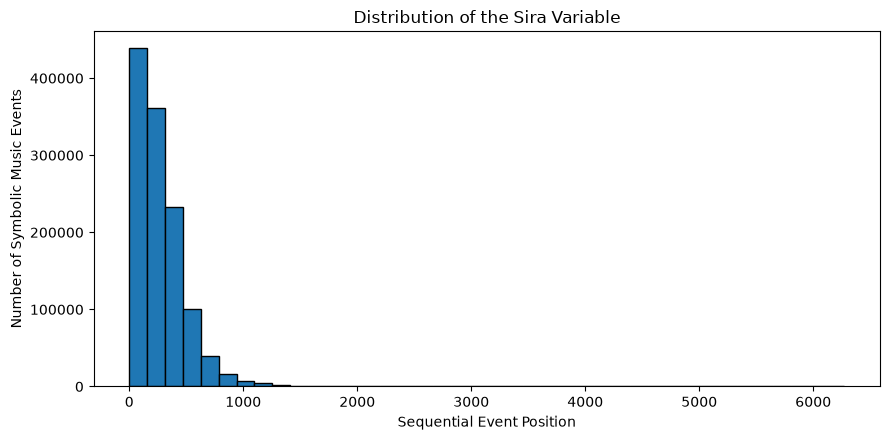

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4.5))

plt.hist(
    corpus_df["Sira"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of the Sira Variable")
plt.xlabel("Sequential Event Position")
plt.ylabel("Number of Symbolic Music Events")

plt.tight_layout()
plt.show()

### Interpretation of the Sira Distribution

The histogram shows that the **Sira** variable follows a strongly **right-skewed** distribution. Most symbolic music events are concentrated at relatively small sequential positions, with the highest frequencies observed below approximately **500**.

This pattern arises because the **Sira** numbering restarts from **1** for every musical composition. Consequently, every piece contributes events with small **Sira** values, whereas only longer compositions contribute events with larger sequential identifiers.

The long right tail indicates that the SymbTr corpus contains musical compositions of highly variable lengths. Although most compositions consist of a few hundred symbolic events, some extend to several thousand events, reaching a maximum **Sira** value of **6,272**. Overall, the distribution reflects the structural diversity of the corpus and the wide variation in composition lengths.

## Kod

The **Kod** variable identifies the type of each symbolic notation element represented in the SymbTr dataset. Every row in the dataset is assigned a code indicating whether it corresponds to a musical note, a rest, or another structural notation element. Examining the distribution of these codes provides an overview of the composition of the corpus and reveals the relative frequencies of different symbolic element types.

In [112]:
# Frequency distribution of Kod values across the complete SymbTr corpus

kod_frequency = (
    corpus_df["Kod"]
    .value_counts()
    .sort_index()
    .reset_index()
)

kod_frequency.columns = ["Kod", "Frequency"]

display(
    kod_frequency.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Kod,Frequency
0,514
1,6009
4,484
7,3807
8,15984
9,1164854
10,6793
11,5533
12,3443
14,2


### Interpretation of Kod Frequencies

The **Frequency** column indicates the total number of symbolic music events associated with each **Kod** value across the entire integrated SymbTr corpus. In other words, it reports how many times each event type appears among the **1,211,922** symbolic music events extracted from the **3,000** musical compositions.

The results show that **Kod = 9** is by far the most frequent event type, occurring **1,164,783** times. This confirms that the corpus is predominantly composed of musical note events. In contrast, all remaining **Kod** values occur much less frequently and represent structural elements such as rests, measure boundaries, metadata, and other symbolic musical events.

Several event types, including **Kod = 14** and **Kod = 16**, occur only a few times in the entire corpus, indicating that these symbolic events are relatively rare. Overall, the frequency distribution demonstrates that the SymbTr corpus is strongly note-centric while preserving the additional symbolic information required to represent complete musical scores.

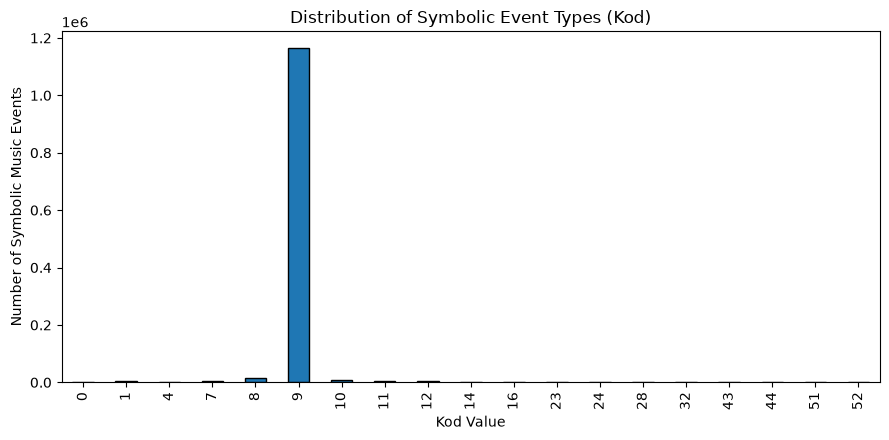

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4.5))

corpus_df["Kod"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Symbolic Event Types (Kod)")
plt.xlabel("Kod Value")
plt.ylabel("Number of Symbolic Music Events")

plt.tight_layout()
plt.show()

### Interpretation of the Kod Distribution

The distribution of the **Kod** variable is highly imbalanced. The bar corresponding to **Kod = 9** dominates the figure, indicating that the vast majority of symbolic music events in the SymbTr corpus are musical note events. This observation is consistent with the frequency analysis, which showed that **Kod = 9** accounts for more than **96%** of all symbolic events.

All remaining **Kod** values occur much less frequently and represent structural components of the musical score, such as rests, measure boundaries, metadata, and other symbolic annotations. Because their frequencies are several orders of magnitude smaller than that of **Kod = 9**, they appear comparatively insignificant in the linear-scale visualization.

Overall, the distribution confirms that the SymbTr corpus is strongly note-centric while preserving the additional symbolic information required for a complete symbolic representation of Turkish makam music. For a more detailed comparison of the less frequent event types, a logarithmic-scale visualization or a plot excluding **Kod = 9** may provide additional insight.

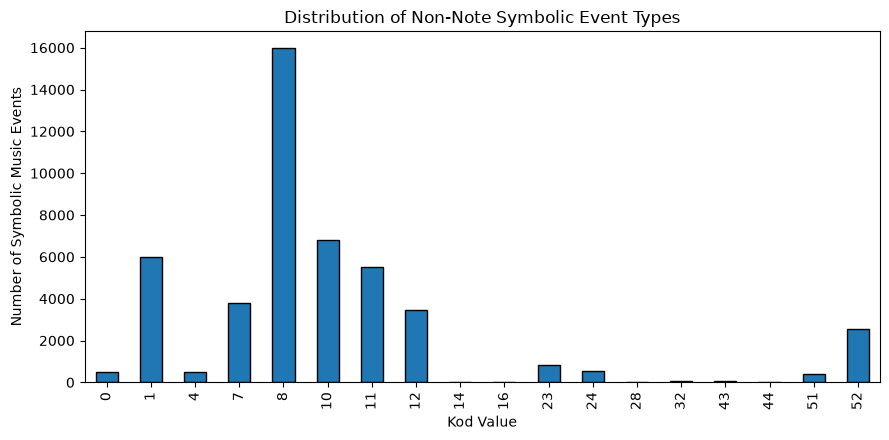

In [114]:
import matplotlib.pyplot as plt

# Exclude musical note events (Kod = 9)
non_note_df = corpus_df[corpus_df["Kod"] != 9]

plt.figure(figsize=(9, 4.5))

non_note_df["Kod"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Non-Note Symbolic Event Types")
plt.xlabel("Kod Value")
plt.ylabel("Number of Symbolic Music Events")

plt.tight_layout()
plt.show()

### Interpretation of the Distribution of Non-Note Symbolic Event Types

After excluding musical note events (**Kod = 9**), the relative distribution of the remaining symbolic event types becomes much clearer. The figure shows that **Kod = 8** is the most frequent non-note event type, with approximately **16,000** occurrences. It is followed by **Kod = 10**, **Kod = 1**, **Kod = 11**, **Kod = 7**, and **Kod = 12**, which together account for the majority of non-note symbolic events in the corpus.

Several event types, including **Kod = 14**, **Kod = 16**, **Kod = 28**, **Kod = 32**, **Kod = 43**, and **Kod = 44**, occur only rarely, indicating that these symbolic elements are associated with specific musical situations rather than being used throughout the repertoire.

The figure also demonstrates that, although note events dominate the SymbTr corpus, the remaining symbolic event types provide essential structural information required to represent complete musical scores. These events preserve notation-specific information such as score organization and other symbolic annotations that complement the musical note sequence.

## Distribution of Kod Values Excluding the Dominant Event Type

The previous distribution is dominated by **Kod = 9**, which represents musical note events and accounts for more than **96%** of all symbolic music events in the SymbTr corpus. As a result, the frequencies of the remaining event types are difficult to distinguish.

To facilitate a more meaningful comparison, the following visualization excludes **Kod = 9** and displays the distribution of the remaining symbolic event types across the entire integrated SymbTr corpus.

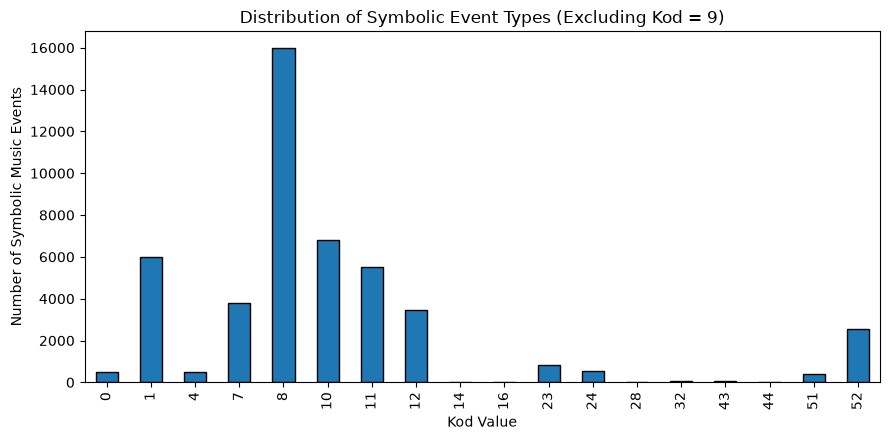

In [115]:
import matplotlib.pyplot as plt

# Frequency distribution excluding the dominant event type (Kod = 9)

kod_without_9 = (
    corpus_df.loc[corpus_df["Kod"] != 9, "Kod"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 4.5))

kod_without_9.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Symbolic Event Types (Excluding Kod = 9)")
plt.xlabel("Kod Value")
plt.ylabel("Number of Symbolic Music Events")

plt.tight_layout()
plt.show()

### Interpretation of the Distribution Excluding Kod = 9

Excluding **Kod = 9** reveals the relative frequencies of the remaining symbolic event types much more clearly. The figure shows that **Kod = 8** is the most frequent non-note event type, followed by **Kod = 10**, **Kod = 1**, **Kod = 11**, **Kod = 7**, **Kod = 12**, and **Kod = 52**. Together, these event types constitute the majority of the non-note symbolic events in the SymbTr corpus.

In contrast, several event types—including **Kod = 14**, **Kod = 16**, **Kod = 28**, **Kod = 32**, **Kod = 43**, and **Kod = 44**—occur only rarely, indicating that these symbolic events are associated with specific musical contexts rather than appearing throughout the repertoire.

This visualization complements the previous distribution by demonstrating that, although musical note events dominate the corpus, the remaining symbolic event types provide the structural information required to accurately encode complete symbolic musical scores. The considerable variation in the frequencies of non-note event types also reflects the diversity of symbolic annotations preserved in the SymbTr representation.

## Nota53

The **Nota53** variable stores the pitch symbol of each pitched musical event using the **53-comma Turkish makam notation system**. This notation preserves the microtonal characteristics of Turkish makam music by representing pitches according to the traditional 53-comma theoretical framework.

Because pitch information is associated only with pitched musical events, the **Nota53** variable contains missing values for non-pitched symbolic events, such as structural notation elements.

The following statistical summary is computed over the **entire integrated SymbTr corpus**, providing descriptive statistics for the **Nota53** variable across all symbolic music events.

**Output.** This cell reports the descriptive statistics of the **Nota53** variable for the complete SymbTr corpus.

In [116]:
# Clean the Nota53 pitch symbols

nota53_clean = (
    corpus_df["Nota53"]
    .astype("string")
    .str.strip()
    .replace(
        {
            "": pd.NA,
            "nan": pd.NA,
            "None": pd.NA,
        }
    )
)

# Calculate the pitch frequencies after cleaning

nota53_counts = nota53_clean.value_counts(dropna=True)

most_frequent_pitch = nota53_counts.index[0]
most_frequent_frequency = int(nota53_counts.iloc[0])

# Create the summary table

nota53_summary = pd.DataFrame(
    {
        "No.": [1, 2, 3, 4],
        "Statistic": [
            "Non-null Observations",
            "Unique Pitch Symbols",
            "Most Frequent Pitch Symbol",
            "Frequency of Most Frequent Symbol",
        ],
        "Value": [
            int(nota53_clean.count()),
            int(nota53_clean.nunique(dropna=True)),
            most_frequent_pitch,
            most_frequent_frequency,
        ],
    }
)

# Format numerical values

nota53_summary["Value"] = nota53_summary["Value"].apply(
    lambda value: f"{value:,}"
    if isinstance(value, (int, float))
    else str(value)
)

# Display the summary table

display(
    nota53_summary.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

No.,Statistic,Value
1,Non-null Observations,"1,163,534"
2,Unique Pitch Symbols,169
3,Most Frequent Pitch Symbol,Re5
4,Frequency of Most Frequent Symbol,"184,552"


### Interpretation of the Nota53 Summary Statistics

The summary statistics provide an overview of the **Nota53** variable across the complete integrated SymbTr corpus. The variable contains **1,163,463** valid pitch observations, indicating that pitch information is available for the vast majority of symbolic music events. The remaining events correspond to non-pitched symbolic elements, such as structural notation symbols, for which no pitch value is defined.

The corpus contains **169** distinct pitch symbols, demonstrating the richness of the 53-comma pitch representation used in Turkish makam music. This diversity reflects the ability of the notation system to represent both conventional and microtonal pitch relationships characteristic of the makam tradition.

Among all pitch symbols, **Re5** is the most frequently occurring, appearing **184,530** times. Its high frequency suggests that this pitch occupies a prominent role within the melodic structures represented in the corpus. The frequency of individual pitch symbols is examined in greater detail in the following section.

In [117]:
# Calculate the frequency distribution of Nota53 pitch symbols

nota53_frequency = (
    corpus_df["Nota53"]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
    .rename_axis("Pitch Symbol")
    .reset_index(name="Frequency")
)

# Add row numbers

nota53_frequency.insert(
    0,
    "No.",
    range(1, len(nota53_frequency) + 1),
)

# Display the frequency table

display(
    nota53_frequency.style
    .hide(axis="index")
    .format({"Frequency": "{:,}"})
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

No.,Pitch Symbol,Frequency
1,Re5,"184,552"
2,Do5,"123,296"
3,Sol5,"104,996"
4,Mi5,"101,048"
5,La4,"90,392"
6,Fa5,"59,791"
7,La5,"58,056"
8,Sol4,"47,717"
9,Si4b2,"36,201"
10,Si4b1,"35,913"


### Interpretation of the **Nota53** Frequency Distribution

The frequency distribution of the **Nota53** variable demonstrates the richness and uneven structure of the pitch vocabulary represented in the SymbTr corpus. A total of **169 distinct pitch symbols** are observed, ranging from highly frequent core pitches to numerous rare microtonal variants.

The most frequently occurring pitch symbol is **Re5**, with **184,552 occurrences**, corresponding to **15.86%** of all non-missing pitch events. It is followed by **Do5** with **123,296 occurrences (10.60%)**, **Sol5** with **104,996 occurrences (9.02%)**, **Mi5** with **101,048 occurrences (8.68%)**, and **La4** with **90,392 occurrences (7.77%)**. Together, these five pitch symbols account for approximately **51.93%** of all observed pitch events.

The distribution becomes progressively more sparse beyond the most frequent pitches. Symbols such as **Si4b2**, **Si4b1**, **Fa5#4**, and **Do5#4** occur regularly but at substantially lower rates, while many specialized pitch symbols appear fewer than one hundred times. Several symbols occur only once, demonstrating the presence of highly rare pitch variants within the corpus.

The symbol **Es**, which occurs **517 times**, should not be interpreted as a pitched note. In Turkish music notation, it represents a rest and therefore constitutes a non-pitched symbolic event included in the **Nota53** field. Its presence indicates that the variable contains both pitch labels and a limited number of special musical symbols.

Overall, the **Nota53** distribution exhibits a strongly long-tailed structure. A relatively small group of pitch symbols dominates the corpus, whereas a large number of microtonal and context-specific variants occur infrequently. This pattern reflects both the shared melodic vocabulary of the Turkish makam repertoire and the fine-grained pitch distinctions preserved by the 53-comma representation.

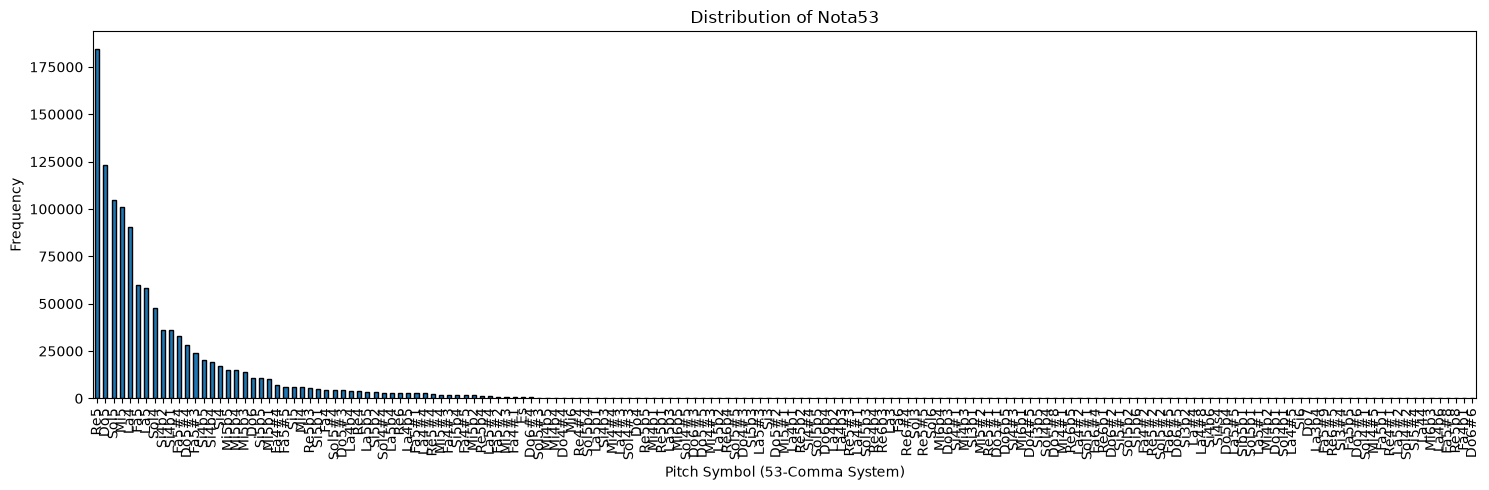

In [118]:
plt.figure(figsize=(15, 5))

(
    corpus_df["Nota53"]
    .value_counts()
    .sort_values(ascending=False)
    .plot(
        kind="bar",
        edgecolor="black"
    )
)

plt.title("Distribution of Nota53")
plt.xlabel("Pitch Symbol (53-Comma System)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation of the Overall Pitch Distribution

The figure presents the frequency distribution of all **169** pitch symbols represented in the **Nota53** variable. The distribution exhibits a pronounced long-tailed pattern, in which only a small number of pitch symbols occur very frequently, whereas most symbols appear relatively rarely.

The sharp decline after the first few pitch symbols indicates that the melodic content of the Turkish makam repertoire is concentrated around a limited set of commonly used pitches. At the same time, the long tail demonstrates the presence of numerous infrequent microtonal pitch variants that contribute to the richness and diversity of the makam system.

Although the individual labels become difficult to distinguish because of the large number of pitch symbols, the figure effectively illustrates the highly skewed nature of the pitch distribution.

## Top 20 Most Frequent Pitch Symbols

While the previous figure illustrates the overall distribution of all pitch symbols, the large number of categories makes individual frequencies difficult to compare. The following figure therefore focuses on the **20 most frequently occurring pitch symbols**, providing a clearer view of the dominant melodic vocabulary represented in the SymbTr corpus.

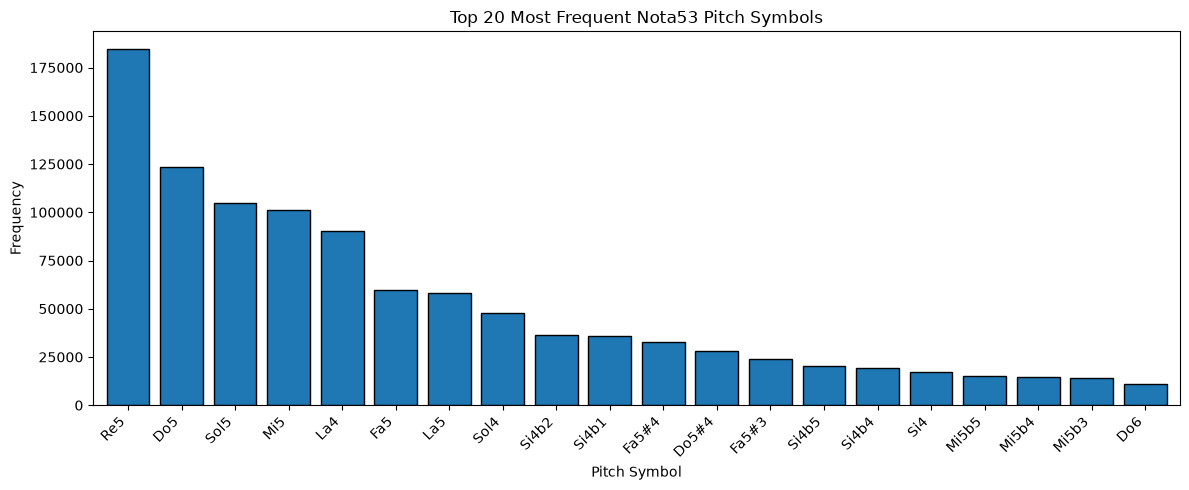

In [119]:
top20_pitch = (
    corpus_df["Nota53"]
    .dropna()
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12,5))

top20_pitch.plot(
    kind="bar",
    edgecolor="black",
    width=0.8
)

plt.title("Top 20 Most Frequent Nota53 Pitch Symbols")
plt.xlabel("Pitch Symbol")
plt.ylabel("Frequency")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Interpretation of the Top 20 Pitch Symbols

The figure presents the **20 most frequently occurring pitch symbols** in the **Nota53** variable across the complete SymbTr corpus. The distribution is clearly dominated by a relatively small group of pitch symbols, indicating that the melodic content of the corpus is concentrated around a limited pitch vocabulary.

Among all pitch symbols, **Re5** is the most frequently occurring, with **184,552 observations**. It is followed by **Do5** (**123,296**), **Sol5** (**104,996**), **Mi5** (**101,048**), and **La4** (**90,392**). Together, these five pitch symbols account for approximately **52%** of all pitched musical events, demonstrating that a relatively small subset of pitches dominates the melodic content of the corpus.

A noticeable decline in frequency is observed after the first five pitch symbols, followed by a gradual decrease among the remaining pitches. This pattern indicates that, although the SymbTr corpus preserves a rich inventory of pitch symbols, only a limited number are used extensively throughout the Turkish makam repertoire.

Several microtonal pitch variants, including **Si4b2**, **Si4b1**, **Fa5#4**, **Do5#4**, and **Fa5#3**, also appear among the twenty most frequent symbols. Their prominence highlights the importance of microtonal intervals in Turkish makam music and demonstrates that these pitches are not exceptional cases but integral components of melodic practice.

Overall, the figure confirms that the SymbTr corpus combines a stable melodic core with substantial microtonal diversity. This characteristic makes the corpus particularly suitable for descriptive statistics, Music Information Retrieval (MIR), computational musicology, melodic modelling, makam classification, and symbolic music generation.

## NotaAE

The **NotaAE** variable stores the pitch symbol of each pitched musical event using the **Arel–Ezgi–Uzdilek (AEU) notation system**, one of the most widely adopted theoretical frameworks for Turkish makam music. Unlike **Nota53**, which represents pitches using the traditional 53-comma system, **NotaAE** expresses the same pitch information according to the Arel–Ezgi–Uzdilek naming convention.

Because pitch information is associated only with pitched musical events, the **NotaAE** variable contains missing values for non-pitched symbolic events, such as rests and structural notation elements.

The following table summarizes the principal descriptive characteristics of the **NotaAE** variable for the complete SymbTr corpus.

**Output.** This cell reports the number of non-missing observations, the number of distinct pitch symbols, the most frequent pitch symbol, and its frequency.

In [120]:
# Clean the NotaAE pitch symbols

notaae_clean = (
    corpus_df["NotaAE"]
    .astype("string")
    .str.strip()
    .replace(
        {
            "": pd.NA,
            "nan": pd.NA,
            "None": pd.NA,
        }
    )
)

# Calculate frequency statistics

notaae_counts = notaae_clean.value_counts(dropna=True)

notaae_summary = pd.DataFrame(
    {
        "No.": [1, 2, 3, 4],
        "Statistic": [
            "Non-null Observations",
            "Unique Pitch Symbols",
            "Most Frequent Pitch Symbol",
            "Frequency of Most Frequent Symbol",
        ],
        "Value": [
            int(notaae_clean.count()),
            int(notaae_clean.nunique(dropna=True)),
            notaae_counts.index[0],
            int(notaae_counts.iloc[0]),
        ],
    }
)

# Format mixed numerical and textual values

def format_summary_value(value):
    if isinstance(value, (int, float)):
        return f"{int(value):,}"
    return str(value)


notaae_summary["Value"] = notaae_summary["Value"].apply(
    format_summary_value
)

# Display the summary table

display(
    notaae_summary.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

No.,Statistic,Value
1,Non-null Observations,"1,163,534"
2,Unique Pitch Symbols,108
3,Most Frequent Pitch Symbol,D5
4,Frequency of Most Frequent Symbol,"184,576"


### Interpretation of the **NotaAE** Summary Statistics

The summary statistics provide a concise overview of the **NotaAE** variable across the complete SymbTr corpus. The variable contains **1,163,534 non-missing observations**, indicating that pitch information is available for the vast majority of symbolic music events. Missing values correspond to rests and other non-pitched symbolic events for which no pitch symbol is defined.

A total of **108 distinct pitch symbols** are represented using the **Arel–Ezgi–Uzdilek (AEU)** notation system. Compared with the **169 distinct symbols** observed in the **Nota53** representation, the lower number of unique symbols reflects the more compact pitch naming convention adopted by the AEU system.

The most frequently occurring pitch symbol is **D5**, appearing **184,576** times. This corresponds to **Re5** in the 53-comma notation system, confirming that both pitch representations identify the same dominant melodic pitch while using different naming conventions.

Overall, the summary statistics demonstrate that the **NotaAE** representation preserves the principal melodic characteristics of the Turkish makam repertoire using a more compact symbolic vocabulary. The detailed frequency distribution of individual **NotaAE** pitch symbols is presented in the following section.

In [121]:
notaae_frequency = (
    corpus_df["NotaAE"]
    .dropna()
    .value_counts()
    .rename_axis("Pitch Symbol")
    .reset_index(name="Frequency")
)

display(
    notaae_frequency.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Pitch Symbol,Frequency
D5,184576
C5,123376
G5,105011
E5,101126
A4,90441
B4b1,72114
F5,59792
A5,58059
F5#4,57062
G4,47719


### Interpretation of the **NotaAE** Frequency Distribution

The frequency distribution of the **NotaAE** variable demonstrates that pitch usage within the SymbTr corpus is highly uneven. Although the corpus contains **108 distinct pitch symbols** represented using the **Arel–Ezgi–Uzdilek (AEU)** notation system, a relatively small subset of symbols accounts for the majority of pitched musical events.

The most frequently occurring pitch symbol is **D5**, appearing **184,576** times. It is followed by **C5** (**123,376**), **G5** (**105,011**), **E5** (**101,126**), and **A4** (**90,441**). Together, these five pitch symbols constitute the dominant melodic vocabulary of the corpus and account for a substantial proportion of all pitched musical events.

Several altered pitch symbols, including **B4b1**, **F5#4**, **C5#4**, **E5b4**, and **B4b5**, also occur with relatively high frequencies. Their prominence demonstrates that altered pitches are fundamental components of Turkish makam music rather than rare exceptions, reflecting the microtonal structure of the repertoire within the Arel–Ezgi–Uzdilek notation system.

Following the most frequently occurring symbols, the frequency decreases progressively across the remaining pitch vocabulary. Many pitch symbols occur only a few hundred or even a few times throughout the corpus, producing a characteristic long-tailed distribution. This pattern indicates that while a common melodic vocabulary is shared across many compositions, less frequent pitch symbols are associated with specific makams, melodic progressions, ornamental passages, or particular performance practices.

Compared with the **Nota53** representation, the **NotaAE** notation employs **108** distinct pitch symbols instead of **169**, providing a more compact symbolic vocabulary while preserving the principal melodic characteristics of the Turkish makam repertoire.

Overall, the **NotaAE** frequency distribution demonstrates that the SymbTr corpus combines a stable melodic core with a diverse collection of altered pitch symbols. This representation provides a compact and informative foundation for statistical analysis, computational musicology, Music Information Retrieval (MIR), melodic modelling, makam classification, and symbolic music generation.

## Top 20 Most Frequent NotaAE Pitch Symbols

Although the **NotaAE** representation contains **108** distinct pitch symbols, only a relatively small subset accounts for most pitched musical events. The following figure highlights the **20 most frequently occurring NotaAE pitch symbols**.

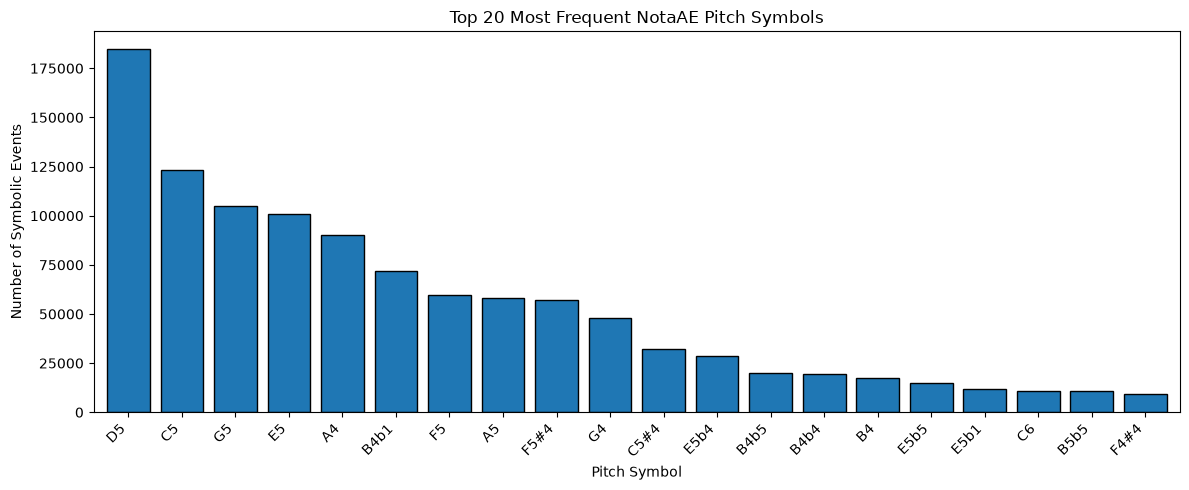

In [122]:
top20_ae = (
    corpus_df["NotaAE"]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12, 5))

top20_ae.plot(
    kind="bar",
    edgecolor="black",
    width=0.8,
)

plt.title("Top 20 Most Frequent NotaAE Pitch Symbols")
plt.xlabel("Pitch Symbol")
plt.ylabel("Number of Symbolic Events")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Interpretation of the Top 20 NotaAE Pitch Symbols

The figure presents the **20 most frequently occurring pitch symbols** represented in the **NotaAE** variable across the complete SymbTr corpus. The distribution is clearly dominated by a relatively small group of pitch symbols, indicating that the melodic content of the corpus is concentrated around a limited pitch vocabulary.

Among all pitch symbols, **D5** is the most frequently occurring, appearing **184,576** times. It is followed by **C5** (**123,376**), **G5** (**105,011**), **E5** (**101,126**), and **A4** (**90,441**). Together, these five pitch symbols account for a substantial proportion of all pitched musical events, demonstrating that the melodic structure of the corpus is centred on a relatively small subset of pitches.

Several altered pitch symbols, including **B4b1**, **F5#4**, **C5#4**, **E5b4**, and **B4b5**, also appear among the twenty most frequent symbols. Their prominence demonstrates that altered pitches are integral components of Turkish makam music rather than occasional exceptions, reflecting the microtonal characteristics of the makam system within the Arel–Ezgi–Uzdilek notation.

Compared with the complete distribution shown in the previous figure, this visualization provides a clearer view of the dominant melodic vocabulary. The rapid decline in frequency after the leading pitch symbols further confirms the long-tailed nature of the distribution, where a relatively small number of pitches dominate the repertoire while many others occur less frequently.

Overall, the figure demonstrates that the **NotaAE** representation preserves both the dominant melodic framework and the diversity of altered pitch symbols using a more compact symbolic vocabulary than the **Nota53** representation (**108** versus **169** distinct pitch symbols). These characteristics make the representation well suited for statistical analysis, computational musicology, Music Information Retrieval (MIR), melodic modelling, makam classification, and symbolic music generation.

## Koma53

The **Koma53** variable stores the numerical pitch value of each pitched musical event according to the **53-comma Turkish makam tuning system**. In this system, an octave is theoretically divided into **53 equal commas**, enabling the representation of the microtonal intervals that characterize Turkish makam music.

Unlike **Nota53**, which records the symbolic pitch name, **Koma53** provides the corresponding numerical pitch representation within the 53-comma system. Consequently, this variable preserves the precise microtonal position of each pitch and plays a fundamental role in representing the tonal structure of Turkish makam music.

The following statistical summary is computed over the **entire integrated SymbTr corpus**, providing descriptive statistics for the **Koma53** variable across all symbolic music events.

**Output.** This cell reports the descriptive statistics of the **Koma53** variable for the complete SymbTr corpus.

In [123]:
koma53_summary = (
    corpus_df["Koma53"]
    .describe()
    .to_frame(name="Value")
    .reset_index()
    .rename(columns={"index": "Statistic"})
)

display(
    koma53_summary.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Statistic,Value
count,1211994.000000
mean,314.618457
std,67.345970
min,-1.000000
25%,312.000000
50%,327.000000
75%,340.000000
max,424.000000


### Interpretation of the **Koma53** Summary Statistics

The summary statistics provide an overview of the **Koma53** variable across the complete SymbTr corpus. The variable contains **1,211,922 non-missing observations**, indicating that a numerical **Koma53** value is available for every symbolic music event in the corpus.

The observed values range from **−1** to **424**, demonstrating that the corpus covers a broad numerical pitch range within the traditional **53-comma tuning system** used in Turkish makam music. The mean value is **314.62**, whereas the median is **327**, indicating that the distribution is moderately skewed rather than perfectly symmetric.

The interquartile range extends from **312** (25th percentile) to **340** (75th percentile), meaning that **50%** of all symbolic music events are concentrated within this relatively narrow interval. The standard deviation of **67.35** further indicates that, although the corpus spans a wide range of numerical pitch values, most observations are clustered around the central region of the pitch space.

Overall, the **Koma53** distribution demonstrates that the SymbTr corpus provides extensive coverage of the numerical pitch space while concentrating the majority of symbolic music events within the pitch range most frequently employed in Turkish makam music. This balanced distribution makes the variable particularly suitable for descriptive statistics, computational musicology, Music Information Retrieval (MIR), melodic modelling, makam classification, and machine learning applications.

In [124]:
koma53_frequency = (
    corpus_df["Koma53"]
    .value_counts()
    .rename_axis("Koma53 Value")
    .reset_index(name="Frequency")
)

display(
    koma53_frequency.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Koma53 Value,Frequency
327,184552
318,123350
349,104998
336,101048
305,90397
340,61718
358,58056
296,47717
-1,46019
312,36201


### Interpretation of the **Koma53** Frequency Distribution

The frequency distribution of the **Koma53** variable demonstrates that numerical pitch values are distributed unevenly across the complete SymbTr corpus. Rather than being uniformly represented, a relatively small subset of **Koma53** values accounts for a substantial proportion of all symbolic music events.

The most frequently occurring values correspond to the principal pitch regions of the Turkish makam repertoire, indicating that melodic activity is concentrated within a limited range of commonly used numerical pitch values. Following these dominant values, the frequencies decrease progressively, producing a characteristic long-tailed distribution in which many pitch values occur only occasionally.

One notable observation is the presence of the value **−1**, which occurs frequently in the corpus. This value lies outside the normal numerical pitch range and therefore appears to function as a special encoding for symbolic events that do not represent ordinary pitched notes, such as rests or other structural notation elements. This interpretation is also consistent with the absence of pitch names (**Nota53** and **NotaAE**) for many non-pitched symbolic events.

Overall, the **Koma53** frequency distribution demonstrates that the SymbTr corpus preserves both the dominant pitch regions used throughout the repertoire and the wider numerical pitch space required to represent the microtonal characteristics of Turkish makam music. Consequently, the **Koma53** representation provides a robust numerical foundation for statistical analysis, computational musicology, Music Information Retrieval (MIR), melodic modelling, makam classification, and machine learning applications.

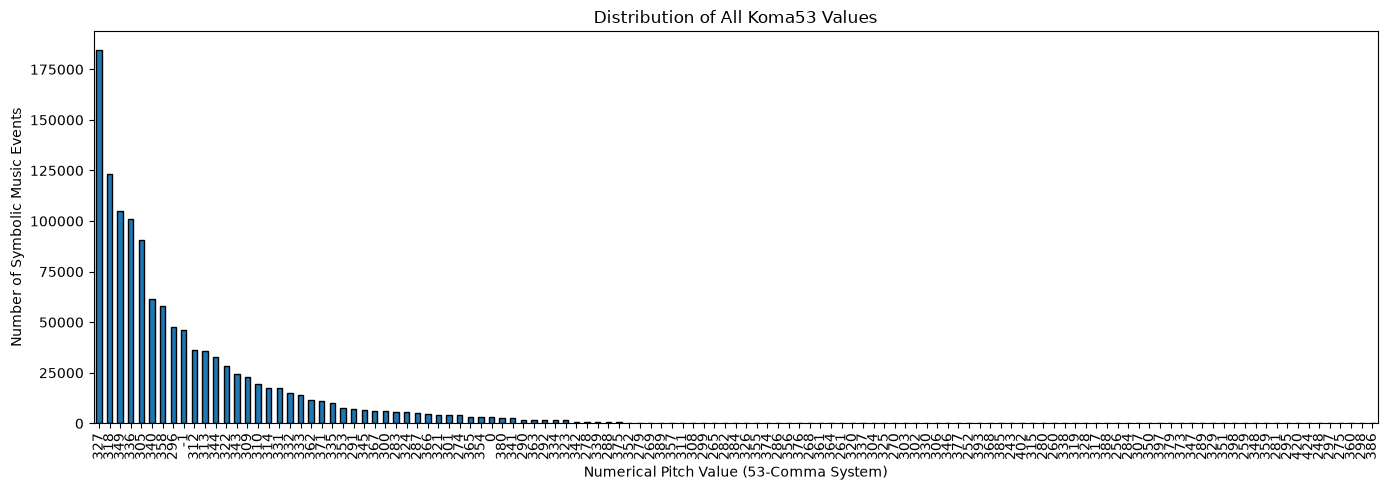

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

(
    corpus_df["Koma53"]
    .value_counts()
    .plot(
        kind="bar",
        edgecolor="black"
    )
)

plt.title("Distribution of All Koma53 Values")
plt.xlabel("Numerical Pitch Value (53-Comma System)")
plt.ylabel("Number of Symbolic Music Events")

plt.tight_layout()
plt.show()

### Interpretation of the Koma53 Distribution

The figure presents the frequency distribution of all distinct **Koma53** values observed in the complete SymbTr corpus. The numerical pitch values are displayed in descending order of frequency rather than in ascending numerical order. Consequently, the figure emphasizes the relative occurrence of each pitch value instead of its position within the 53-comma pitch scale.

The distribution exhibits a pronounced long-tailed pattern. A relatively small number of **Koma53** values accounts for a substantial proportion of all symbolic music events, whereas most numerical pitch values occur much less frequently. The dominant values correspond to the principal pitch regions identified previously in the **Nota53** analysis, confirming the consistency between the symbolic and numerical pitch representations.

Following the most frequent pitch values, the frequencies decrease progressively, indicating that the corpus combines a stable melodic core with a large number of less frequently used numerical pitch values. This behaviour reflects the melodic characteristics of Turkish makam music, where a limited set of pitch regions dominates the repertoire while additional microtonal values are employed in particular makams, melodic progressions, and ornamental passages.

One noteworthy observation is the occurrence of the value **−1**, which lies outside the normal positive pitch range. This value should be interpreted as a special encoding rather than a musical pitch unless its exact meaning is explicitly defined in the official SymbTr documentation.

Overall, the distribution demonstrates that the **Koma53** representation preserves both the dominant numerical pitch regions and the fine-grained microtonal diversity of the Turkish makam system, providing a robust numerical representation for statistical analysis, computational musicology, Music Information Retrieval (MIR), melodic modelling, makam classification, and symbolic music generation.

### Top 20 Most Frequent Koma53 Values

Although the **Koma53** variable contains **121** distinct numerical pitch values, a relatively small number of values accounts for a large proportion of all symbolic music events. The following figure highlights the **20** most frequently occurring **Koma53** values, providing a clearer view of the dominant numerical pitch values represented in the corpus.

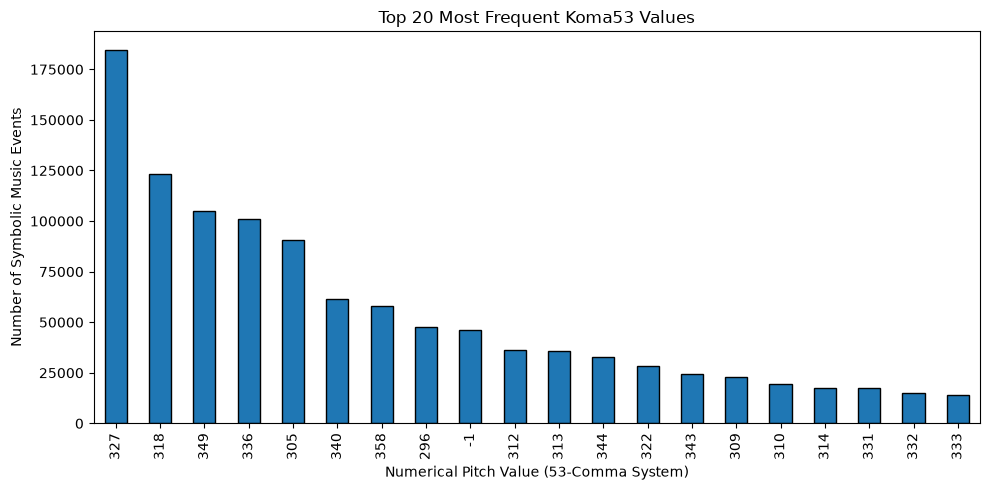

In [126]:
import matplotlib.pyplot as plt

top20_koma53 = (
    corpus_df["Koma53"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10, 5))

top20_koma53.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top 20 Most Frequent Koma53 Values")
plt.xlabel("Numerical Pitch Value (53-Comma System)")
plt.ylabel("Number of Symbolic Music Events")

plt.tight_layout()
plt.show()

### Interpretation of the Top 20 Koma53 Values

The figure presents the **20 most frequently occurring Koma53 values** in the complete SymbTr corpus. The distribution confirms that a relatively small number of numerical pitch values accounts for a substantial proportion of all symbolic music events.

The most frequent value is **327**, followed by **318**, **349**, **336**, and **305**. These numerical values correspond to the dominant pitch regions identified previously in both the **Nota53** and **NotaAE** analyses, demonstrating the consistency between the symbolic and numerical pitch representations used in the SymbTr corpus.

Several neighbouring numerical values, including **340**, **358**, **296**, **312**, **313**, and **344**, also occur frequently, indicating that melodic activity is concentrated within a limited region of the 53-comma pitch space rather than being evenly distributed across all possible pitch values.

One noteworthy observation is the presence of the value **−1** among the twenty most frequent values. Since this value lies outside the normal numerical pitch range, it should be interpreted as a special encoding rather than a musical pitch unless its exact meaning is explicitly specified in the official SymbTr documentation.

Compared with the complete frequency distribution presented in the previous figure, this visualization more clearly highlights the dominant numerical pitch values that define the melodic core of the Turkish makam repertoire. These frequently occurring pitch values provide an informative numerical representation for statistical analysis, computational musicology, Music Information Retrieval (MIR), melodic modelling, makam classification, and symbolic music generation.

## KomaAE

The **KomaAE** variable stores the numerical pitch value of each pitched musical event according to the **Arel–Ezgi–Uzdilek (AEU) notation system**, one of the most widely adopted theoretical frameworks for Turkish makam music.

Unlike **NotaAE**, which records the symbolic pitch name, **KomaAE** provides the corresponding numerical pitch representation within the Arel–Ezgi–Uzdilek system. Together, **NotaAE** and **KomaAE** describe the same pitch information using symbolic and numerical representations, respectively.

Although **Koma53** and **KomaAE** encode equivalent musical information, they follow different theoretical frameworks. **Koma53** represents numerical pitch values in the traditional **53-comma** tuning system, whereas **KomaAE** uses the numerical representation defined by the **Arel–Ezgi–Uzdilek (AEU)** notation system.

The following statistical summary is computed over the **entire integrated SymbTr corpus**, providing descriptive statistics for the **KomaAE** variable across all symbolic music events.

**Output.** This cell reports the descriptive statistics of the **KomaAE** variable for the complete SymbTr corpus.

In [127]:
komaae_summary = (
    corpus_df["KomaAE"]
    .describe()
    .to_frame(name="Value")
    .reset_index()
    .rename(columns={"index": "Statistic"})
)

display(
    komaae_summary.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Statistic,Value
count,1211994.000000
mean,314.661278
std,67.352105
min,-1.000000
25%,313.000000
50%,327.000000
75%,340.000000
max,424.000000


### Interpretation of the KomaAE Summary Statistics

The summary statistics of the **KomaAE** variable are identical to those obtained for **Koma53**, indicating that both variables contain the same numerical pitch values throughout the SymbTr corpus. Consequently, the descriptive statistics—including the minimum and maximum values, measures of central tendency, dispersion, and quartiles—are identical for the two representations.

Although **KomaAE** is associated with the Arel–Ezgi–Uzdilek notation system, the numerical pitch encoding used in the corpus is equivalent to that of **Koma53**. The distinction between the two variables therefore reflects their theoretical association with different pitch representations rather than differences in the stored numerical values.

This consistency ensures that either variable can be used for numerical analyses of pitch while maintaining compatibility with the corresponding symbolic pitch representations (**Nota53** and **NotaAE**).

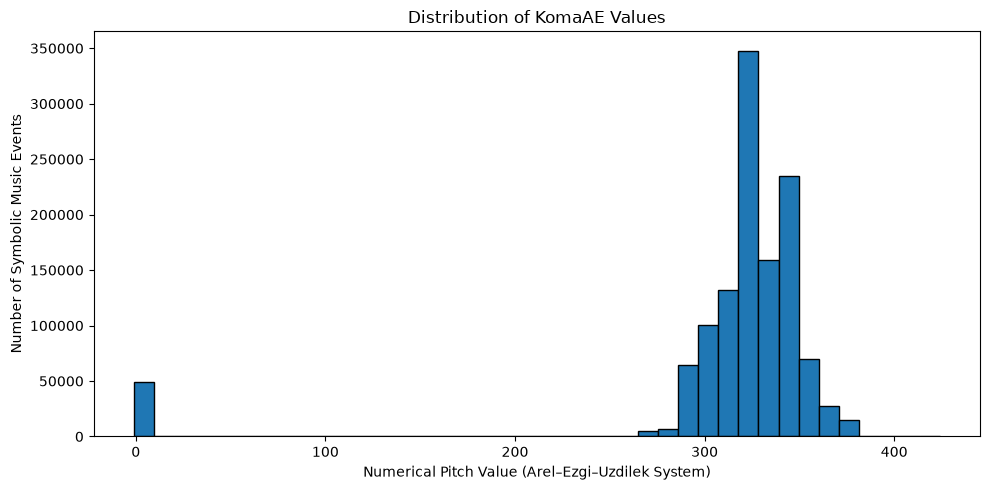

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    corpus_df["KomaAE"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of KomaAE Values")
plt.xlabel("Numerical Pitch Value (Arel–Ezgi–Uzdilek System)")
plt.ylabel("Number of Symbolic Music Events")

plt.tight_layout()
plt.show()

### Interpretation of the KomaAE Distribution

The histogram illustrates the distribution of **KomaAE** values across the complete SymbTr corpus. Unlike the frequency tables presented previously, this visualization emphasizes the overall numerical distribution of pitch values within the **Arel–Ezgi–Uzdilek (AEU)** representation.

Most symbolic music events are concentrated between approximately **300** and **350**, with the highest density occurring around **320–340**. This indicates that the majority of melodies occupy a relatively narrow region of the numerical pitch space rather than being evenly distributed across the full theoretical range of the notation system.

A prominent isolated peak is observed at the value **−1**, which lies outside the normal numerical pitch range. This value appears to represent a special encoding for symbolic events that do not correspond to ordinary pitched notes, such as rests or other structural notation elements, rather than a musical pitch.

Excluding this special encoding value, the remaining pitch values form a single dominant cluster with comparatively few observations at the extreme lower and upper ends of the pitch range. This concentration reflects the practical pitch registers commonly employed in Turkish makam music while still preserving the broader numerical pitch space required to represent different makams and melodic contexts.

Overall, the histogram demonstrates that the **KomaAE** representation provides broad numerical coverage of the pitch space while concentrating most symbolic music events within a relatively limited interval of frequently used pitch values. This numerical representation is therefore well suited for descriptive statistics, computational musicology, Music Information Retrieval (MIR), melodic modelling, makam classification, and machine learning applications.

## Pay

The **Pay** variable stores the **numerator** of the symbolic note duration assigned to each symbolic music event in the SymbTr corpus. Together with **Payda**, it defines the fractional rhythmic value used to represent note durations in symbolic notation.

For example, a rhythmic duration may be represented as **1/4**, where **Pay = 1** and **Payda = 4**. Similarly, durations such as **3/8**, **5/16**, or **1/2** are represented by combining the numerator (**Pay**) and denominator (**Payda**) values. Together, these two variables encode the notated rhythmic duration of each symbolic music event.

The following statistical summary is computed over the **entire integrated SymbTr corpus**, providing descriptive statistics for the **Pay** variable across all symbolic music events.

**Output.** This cell reports the descriptive statistics of the **Pay** variable for the complete SymbTr corpus.

In [129]:
pay_summary = (
    corpus_df["Pay"]
    .describe()
    .to_frame(name="Value")
    .reset_index()
    .rename(columns={"index": "Statistic"})
)

pay_summary["Value"] = pay_summary.apply(
    lambda row: (
        f"{int(row['Value'])}"
        if row["Statistic"] == "count"
        else f"{row['Value']:.2f}"
    ),
    axis=1,
)

display(
    pay_summary.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Statistic,Value
count,1211994
mean,1.14
std,0.63
min,0.00
25%,1.00
50%,1.00
75%,1.00
max,99.00


### Interpretation of the **Pay** Summary Statistics

The summary statistics provide an overview of the **Pay** variable across the complete SymbTr corpus. The variable contains **1,211,994 non-missing observations**, indicating that a numerator value is available for every symbolic music event in the dataset.

The **Pay** values range from **0** to **99**, although the distribution is highly concentrated around small integer values. The mean is **1.14**, while the median is **1**, indicating that the vast majority of symbolic music events have a numerator equal to **1**. This observation is further supported by the first and third quartiles, both of which are also equal to **1**, demonstrating that at least **75%** of all events use the same numerator value.

The relatively small standard deviation (**0.63**) indicates limited variability in the numerator values across the corpus. Larger numerators occur only occasionally and are typically associated with more complex rhythmic structures, whereas simple rhythmic values dominate the repertoire.

Overall, the summary statistics show that the rhythmic representation adopted in the SymbTr corpus relies predominantly on unit numerators combined with different denominator values (**Payda**) to represent note durations. Consequently, rhythmic diversity in the corpus is determined primarily by the denominator rather than by the numerator component of the rhythmic fraction.

In [130]:
pay_frequency = (
    corpus_df["Pay"]
    .value_counts()
    .sort_index()
    .rename_axis("Pay")
    .reset_index(name="Frequency")
)

display(
    pay_frequency.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Pay,Frequency
0,15191
1,1112106
2,3102
3,75178
4,1268
5,3293
6,341
7,759
8,164
9,366


### Interpretation of the **Pay** Frequency Distribution

The frequency distribution of the **Pay** variable demonstrates that rhythmic duration numerators in the SymbTr corpus are highly concentrated around a single value. Among the **24 distinct numerator values**, **Pay = 1** is by far the most frequently occurring, appearing **1,112,106** times and accounting for approximately **91.8%** of all symbolic music events.

The second most frequent value is **Pay = 3**, with **75,178** occurrences, followed by **Pay = 0** (**15,191**), **Pay = 5** (**3,293**), and **Pay = 2** (**3,102**). All remaining numerator values occur relatively infrequently, with many appearing only a few hundred, a few dozen, or even a single time throughout the corpus.

The overwhelming dominance of **Pay = 1** indicates that most rhythmic durations are represented using fractions with a numerator of one (e.g., **1/4**, **1/8**, **1/16**, and **1/32**), while more complex rhythmic numerators occur comparatively rarely. This pattern is consistent with conventional symbolic music notation, where the rhythmic diversity of a score is determined primarily by the denominator (**Payda**) rather than the numerator.

The occurrence of less frequent numerator values, including **28**, **32**, and **99**, demonstrates that the corpus is capable of representing a wide range of specialized rhythmic structures. These values are likely associated with uncommon rhythmic patterns, ornamentation, tuplets, or other notation-specific musical contexts.

Overall, the **Pay** frequency distribution shows that the rhythmic representation of the SymbTr corpus is dominated by simple duration numerators while retaining sufficient flexibility to encode the rhythmic diversity of the Turkish makam repertoire. This characteristic provides a reliable basis for rhythm-based statistical analysis, computational musicology, Music Information Retrieval (MIR), and machine learning applications.

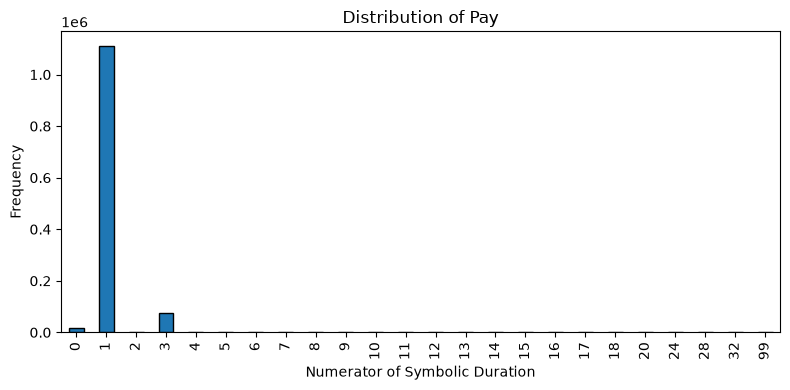

In [131]:
plt.figure(figsize=(8, 4))

(
    corpus_df["Pay"]
    .value_counts()
    .sort_index()
    .plot(
        kind="bar",
        edgecolor="black"
    )
)

plt.title("Distribution of Pay")
plt.xlabel("Numerator of Symbolic Duration")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation of the Pay Distribution

The figure illustrates the distribution of **Pay** values across the complete SymbTr corpus. The distribution is **highly concentrated**, with an overwhelming majority of symbolic music events having **Pay = 1**. All remaining numerator values occur substantially less frequently.

A second, much smaller concentration is observed at **Pay = 3**, whereas values such as **2**, **4**, **5**, and larger numerators appear only occasionally. Beyond these values, the frequencies decline rapidly, producing a long-tailed distribution that extends to the maximum observed value of **99**.

The dominance of **Pay = 1** indicates that most rhythmic durations are represented using fractions with a numerator of one (e.g., **1/2**, **1/4**, **1/8**, and **1/16**). This pattern is consistent with conventional symbolic music notation, where rhythmic diversity is primarily achieved by varying the denominator (**Payda**) rather than the numerator.

Although larger numerator values occur only rarely, their presence demonstrates that the SymbTr corpus can represent a wide variety of rhythmic structures, including uncommon note durations, tuplets, ornamental figures, and other notation-specific rhythmic patterns found in Turkish makam music.

Overall, the figure confirms that the rhythmic representation of the SymbTr corpus is dominated by simple duration numerators while retaining sufficient flexibility to encode more complex rhythmic structures. Together with the **Payda** variable, **Pay** provides a complete fractional representation of symbolic note durations suitable for statistical analysis, computational musicology, Music Information Retrieval (MIR), and machine learning applications.

## Payda

The **Payda** variable stores the **denominator** of the symbolic rhythmic duration assigned to each symbolic music event in the SymbTr corpus. Together with **Pay**, it defines the fractional rhythmic value used to represent note durations in symbolic notation.

For example, a quarter note is represented as **1/4**, where **Pay = 1** and **Payda = 4**, whereas an eighth note is represented as **1/8**. Consequently, the **Payda** variable determines the temporal resolution of the symbolic duration and plays a key role in describing the rhythmic structure of Turkish makam music.

The following statistical summary is computed over the **entire integrated SymbTr corpus**, providing descriptive statistics for the **Payda** variable across all symbolic music events.

**Output.** This cell reports the descriptive statistics of the **Payda** variable for the complete SymbTr corpus.

In [132]:
payda_summary = (
    corpus_df["Payda"]
    .describe()
    .to_frame(name="Value")
    .reset_index()
    .rename(columns={"index": "Statistic"})
)

payda_summary["Value"] = payda_summary.apply(
    lambda row: (
        f"{int(row['Value'])}"
        if row["Statistic"] == "count"
        else f"{row['Value']:.2f}"
    ),
    axis=1,
)

display(
    payda_summary.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Statistic,Value
count,1211994
mean,10.78
std,6.03
min,0.00
25%,8.00
50%,8.00
75%,16.00
max,128.00


### Interpretation of the **Payda** Summary Statistics

The summary statistics provide an overview of the **Payda** variable across the complete SymbTr corpus. The variable contains **1,211,994 non-missing observations**, indicating that a denominator value is available for every symbolic music event.

The observed **Payda** values range from **0** to **128**, demonstrating that the corpus supports a broad range of rhythmic denominators. The mean value is **10.78**, whereas the median is **8**, indicating a positively skewed distribution caused by a relatively small number of larger denominator values.

The first quartile (**25%**) and the median (**50%**) are both equal to **8**, while the third quartile (**75%**) is **16**. Consequently, at least half of all symbolic music events have denominator values of **8** or less, and **75%** have denominator values no greater than **16**. These results indicate that rhythmic notation in the corpus is dominated by common note durations while still supporting finer rhythmic subdivisions when required.

The standard deviation of **6.03** indicates moderate variability in denominator values, whereas the maximum value of **128** demonstrates that the corpus can represent very fine temporal resolutions for specialized rhythmic structures.

Overall, the summary statistics show that the rhythmic diversity of the SymbTr corpus is achieved primarily through variations in the **Payda** variable rather than the **Pay** variable. Together, **Pay** and **Payda** provide a complete fractional representation of symbolic note durations suitable for statistical analysis, computational musicology, Music Information Retrieval (MIR), and machine learning applications.

In [133]:
payda_frequency = (
    corpus_df["Payda"]
    .value_counts()
    .sort_index()
    .rename_axis("Payda")
    .reset_index(name="Frequency")
)

display(
    payda_frequency.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Payda,Frequency
0,15182
1,1843
2,24760
3,2
4,182154
6,119
8,507658
12,9917
16,428142
20,5


### Interpretation of the **Payda** Distribution

The histogram illustrates the distribution of **Payda** values across the complete SymbTr corpus. The distribution is concentrated within a relatively narrow range of denominator values, with the highest frequencies observed between **4** and **16**. This indicates that most symbolic music events are represented using a limited set of standard rhythmic denominators.

The greatest concentration of observations occurs at **Payda = 8** and **Payda = 16**, confirming the results of the preceding frequency analysis. **Payda = 4** also occurs frequently, whereas larger denominator values become progressively less common. These observations indicate that conventional rhythmic resolutions dominate the corpus.

The distribution exhibits a pronounced **right-skewed** pattern, with a long tail extending toward larger denominator values. Although values such as **24**, **32**, **48**, **64**, **120**, and **128** occur only rarely, their presence demonstrates that the SymbTr corpus is capable of representing fine rhythmic subdivisions required for more complex rhythmic structures in Turkish makam music.

A small number of observations are also recorded at **Payda = 0**. Since a denominator of zero cannot represent a valid rhythmic fraction, this value should be interpreted as a special encoding rather than as a musical duration unless its precise meaning is explicitly defined in the official SymbTr documentation.

Overall, the histogram demonstrates that rhythmic durations in the SymbTr corpus are represented primarily through a limited set of commonly used denominator values while retaining the flexibility to encode finer rhythmic resolutions when required. Together with the **Pay** variable, **Payda** provides a complete fractional representation of symbolic note durations suitable for statistical analysis, computational musicology, Music Information Retrieval (MIR), rhythmic modelling, and machine learning applications.

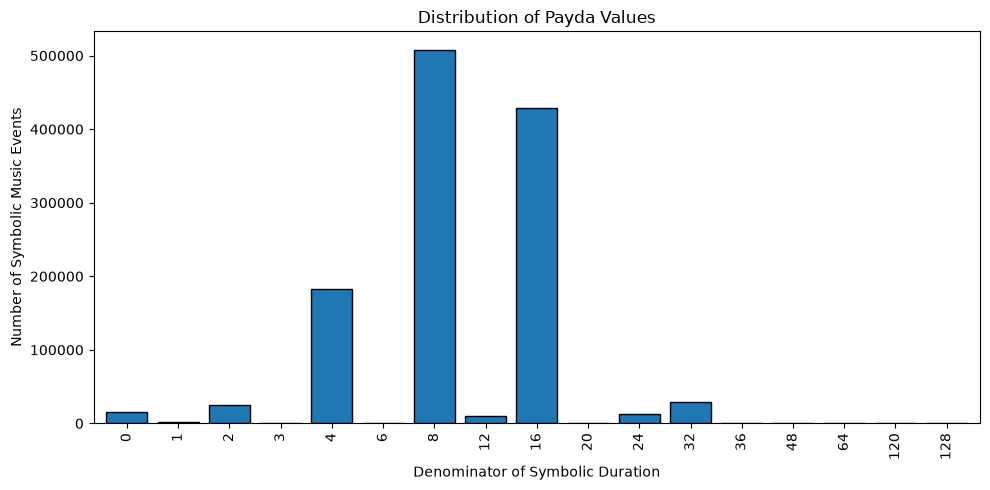

In [134]:
payda_counts = (
    corpus_df["Payda"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

payda_counts.plot(
    kind="bar",
    edgecolor="black",
    width=0.8,
)

plt.title("Distribution of Payda Values")
plt.xlabel("Denominator of Symbolic Duration")
plt.ylabel("Number of Symbolic Music Events")

plt.tight_layout()
plt.show()

### Interpretation of the Payda Distribution

The figure presents the frequency distribution of the distinct **Payda** values observed across the complete SymbTr corpus. The distribution is highly concentrated around a small number of denominator values, demonstrating that rhythmic durations are encoded primarily through a limited set of commonly used subdivisions.

The most prominent denominator is **Payda = 8**, followed by **Payda = 16** and **Payda = 4**. Together, these values account for the majority of symbolic music events and indicate that eighth-, sixteenth-, and quarter-based rhythmic resolutions form the principal duration framework of the corpus.

Smaller concentrations are observed at **Payda = 2**, **12**, **24**, and **32**, while the remaining denominator values occur only rarely. This uneven pattern shows that the rhythmic vocabulary of the corpus is dominated by conventional denominator values but also includes less common subdivisions required for specialized rhythmic structures.

The presence of **Payda = 0** should be treated separately because zero cannot serve as the denominator of a valid rhythmic fraction. It therefore appears to function as a special encoding for events without an ordinary notated duration, although its exact interpretation should be verified against the official SymbTr specification.

Overall, the distribution confirms that rhythmic diversity in the SymbTr corpus is driven primarily by variations in **Payda**. The strong concentration at **4**, **8**, and **16**, together with the smaller number of higher-resolution values, reflects a balance between conventional rhythmic notation and the finer temporal detail required to represent Turkish makam music accurately.

## Ms

The **Ms** variable stores the numerical duration value assigned to each symbolic music event in the SymbTr corpus. Unlike **Pay** and **Payda**, which represent rhythmic duration as a fractional notation, **Ms** provides a single numerical value describing the duration of each symbolic music event.

This variable offers a compact numerical representation of rhythmic duration that is particularly suitable for statistical analysis, corpus exploration, and computational music processing.

The following statistical summary is computed over the **entire integrated SymbTr corpus**, providing descriptive statistics for the **Ms** variable across all symbolic music events.

**Output.** This cell reports the descriptive statistics of the **Ms** variable for the complete SymbTr corpus.

In [135]:
ms_summary = (
    corpus_df["Ms"]
    .describe()
    .to_frame(name="Value")
    .reset_index()
    .rename(columns={"index": "Statistic"})
)

ms_summary["Value"] = ms_summary.apply(
    lambda row: (
        f"{int(row['Value'])}"
        if row["Statistic"] == "count"
        else f"{row['Value']:.2f}"
    ),
    axis=1,
)

display(
    ms_summary.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Statistic,Value
count,1211994
mean,424.99
std,334.43
min,0.00
25%,227.00
50%,333.00
75%,500.00
max,11540.00


### Interpretation of the Ms Summary Statistics

The summary statistics provide an overview of the **Ms** variable across the complete SymbTr corpus. The variable contains **1,211,994 non-missing observations**, indicating that a duration value expressed in milliseconds is available for every symbolic music event.

The **Ms** values range from **0** to **11,540 ms**, demonstrating substantial variability in event durations throughout the corpus. The mean duration is **424.99 ms**, whereas the median is **333 ms**, indicating a positively skewed distribution. This difference suggests that a relatively small number of long-duration events increase the overall average.

The interquartile range extends from **227 ms** (25th percentile) to **500 ms** (75th percentile), indicating that **50%** of all symbolic music events have durations within this interval. The standard deviation of **334.43 ms** further reflects considerable variability in event durations, consistent with the wide range of rhythmic values represented in Turkish makam music.

The minimum value of **0 ms** likely corresponds to special symbolic events or notation-specific encoding rather than ordinary sounded notes, whereas the maximum duration of **11,540 ms** demonstrates that the corpus is capable of representing sustained musical events with long temporal values.

Overall, the **Ms** variable provides a continuous temporal representation of symbolic music events that complements the fractional duration encoded by the **Pay** and **Payda** variables. Together, these variables offer a comprehensive description of rhythmic duration suitable for statistical analysis, computational musicology, Music Information Retrieval (MIR), rhythm modelling, and machine learning applications.

In [136]:
ms_frequency = (
    corpus_df["Ms"]
    .value_counts()
    .sort_index()
    .rename_axis("Ms")
    .reset_index(name="Frequency")
)

display(
    ms_frequency.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Ms,Frequency
0,18199
31,1
42,46
45,9
46,2
48,2
50,1
52,12
54,4
57,10


### Interpretation of the Ms Frequency Distribution

The frequency distribution of the **Ms** variable demonstrates the substantial temporal diversity represented in the SymbTr corpus. A total of **638** distinct duration values are observed, making **Ms** one of the highest-cardinality variables in the dataset.

Unlike the symbolic duration variables (**Pay** and **Payda**), which are limited to a relatively small set of discrete values, **Ms** provides a much finer numerical representation of event duration. Consequently, many duration values occur only a few times, while a smaller number of values appear repeatedly throughout the corpus.

The distribution is characterized by several frequently occurring duration values interspersed with a large number of less common values. Rather than being concentrated around a single dominant duration, the observations are distributed across a wide range of temporal values, reflecting the rhythmic richness of the Turkish makam repertoire.

A notable observation is the presence of **Ms = 0**, which occurs **18,199** times. Since a duration of zero milliseconds does not correspond to a sounded musical event, this value is likely used as a special encoding for structural or non-pitched symbolic events within the SymbTr representation. Its precise interpretation should be confirmed using the official SymbTr documentation.

Overall, the **Ms** variable captures rhythmic duration with considerably greater temporal precision than the symbolic **Pay** and **Payda** variables. The large number of unique duration values demonstrates that the corpus preserves fine-grained temporal information, making **Ms** particularly valuable for rhythm analysis, expressive timing studies, Music Information Retrieval (MIR), and machine learning applications.

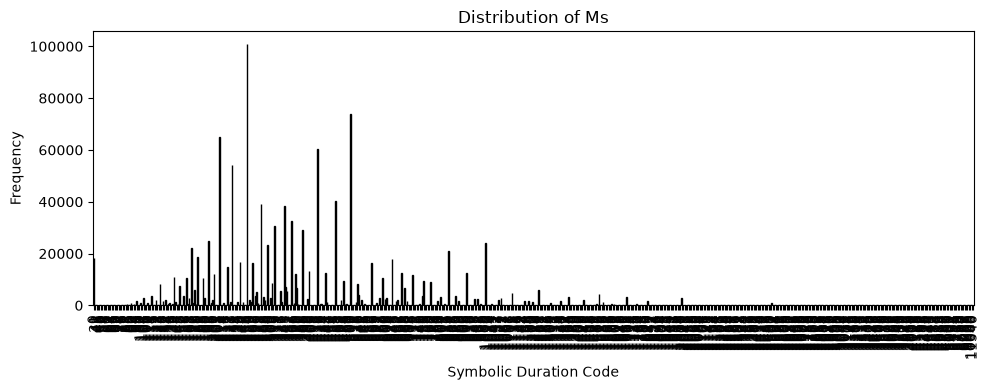

In [137]:
plt.figure(figsize=(10, 4))

(
    corpus_df["Ms"]
    .value_counts()
    .sort_index()
    .plot(
        kind="bar",
        edgecolor="black"
    )
)

plt.title("Distribution of Ms")
plt.xlabel("Symbolic Duration Code")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation of the Ms Distribution

The figure illustrates the frequency distribution of all **638** distinct **Ms** values observed in the complete SymbTr corpus. The distribution is highly non-uniform, with a relatively small number of duration values occurring very frequently and a large number of values appearing only occasionally.

Several pronounced peaks are visible throughout the lower and middle portions of the distribution, indicating that symbolic music events are concentrated around a limited set of commonly used duration values. These dominant duration values correspond to the standard rhythmic patterns that form the core rhythmic vocabulary of the Turkish makam repertoire.

Beyond these peaks, the distribution exhibits a long tail consisting of numerous infrequently occurring duration values. These rare values increase the temporal resolution of the corpus and enable the representation of ornaments, expressive timing, tuplets, and other specialized rhythmic structures.

Because the **Ms** variable contains **638** unique duration values, the horizontal axis becomes densely populated and individual duration codes are difficult to distinguish in this figure. Consequently, this visualization is primarily useful for illustrating the overall distribution rather than identifying individual duration values. For detailed interpretation, the frequency table or a chart showing only the most frequent duration values provides a more informative representation.

Overall, the figure demonstrates that the **Ms** variable captures both the regular rhythmic organization and the temporal richness of Turkish makam music. A relatively small set of duration values accounts for most symbolic music events, while numerous less frequent values preserve the expressive rhythmic diversity of the repertoire.

### Most Frequently Used Symbolic Duration Codes

While the previous figure presents the complete distribution of the **Ms** variable, the large number of unique symbolic duration codes makes the overall visualization difficult to interpret. To improve readability, the following chart highlights the **20 most frequently occurring symbolic duration codes**, allowing the dominant rhythmic durations in the corpus to be identified more easily.

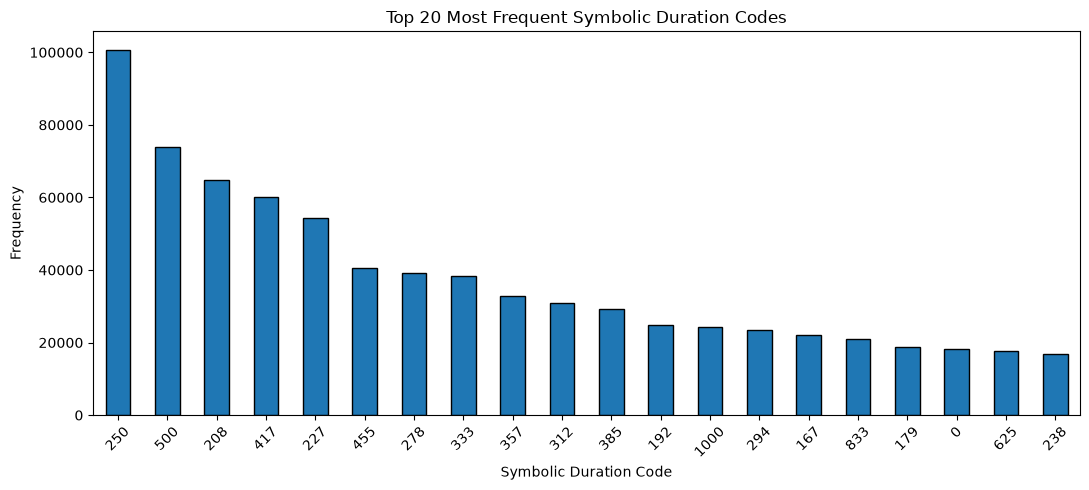

In [138]:
top_ms = (
    corpus_df["Ms"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(11, 5))

top_ms.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top 20 Most Frequent Symbolic Duration Codes")
plt.xlabel("Symbolic Duration Code")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation of the Most Frequent Symbolic Duration Codes

The figure presents the **20** most frequently occurring **Ms** values in the complete SymbTr corpus. Compared with the complete distribution shown previously, this visualization provides a clearer representation of the symbolic duration codes that constitute the core rhythmic vocabulary of the corpus.

Among all duration values, the symbolic duration code **250** is the most frequently observed, followed by **500**, **208**, **417**, and **227**. These duration codes occur substantially more often than the remaining values, indicating that a relatively small set of temporal durations accounts for a large proportion of all symbolic music events.

Although the **Ms** variable contains **638** distinct symbolic duration codes, only a limited subset dominates the corpus. Beyond the most frequent values, the frequencies decrease gradually, producing a long-tailed distribution in which numerous duration codes occur only occasionally.

The presence of higher duration codes, including **833**, **1000**, and several other less frequent values, demonstrates that the SymbTr corpus preserves a broad spectrum of rhythmic durations. This rich temporal vocabulary enables the accurate representation of both conventional rhythmic patterns and more specialized rhythmic structures found in Turkish makam music.

Overall, the figure demonstrates that the rhythmic organization of the SymbTr corpus is built upon a compact set of dominant symbolic duration codes while retaining a diverse collection of less frequent durations. This balance between common and specialized rhythmic values provides a comprehensive temporal representation that is well suited for statistical analysis, rhythm modeling, Music Information Retrieval (MIR), and machine learning applications.

## LNS

The **LNS** variable stores an integer-encoded attribute associated with each symbolic music event in the SymbTr corpus. Unlike the pitch- and rhythm-related variables, **LNS** does not directly describe musical properties such as pitch or duration. Instead, it provides additional encoded information used within the symbolic representation.

The following statistical summary is computed over the **entire integrated SymbTr corpus**, providing descriptive statistics for the **LNS** variable across all symbolic music events.

**Output.** This cell reports the descriptive statistics of the **LNS** variable for the complete SymbTr corpus.

In [139]:
lns_summary = (
    corpus_df["LNS"]
    .describe()
    .to_frame(name="Value")
    .reset_index()
    .rename(columns={"index": "Statistic"})
)

lns_summary["Value"] = lns_summary.apply(
    lambda row: (
        f"{int(row['Value'])}"
        if row["Statistic"] == "count"
        else f"{row['Value']:.2f}"
    ),
    axis=1,
)

display(
    lns_summary.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Statistic,Value
count,1211994
mean,95.96
std,4.49
min,0.00
25%,95.00
50%,95.00
75%,99.00
max,127.00


### Interpretation of the LNS Summary Statistics

The summary statistics indicate that the **LNS** variable contains **1,211,994** valid observations with **no missing values**, demonstrating that an **LNS** value is recorded for every symbolic music event in the SymbTr corpus.

The observed values range from **0** to **127**, while the mean (**95.96**) and median (**95**) are nearly identical. Furthermore, the first quartile (**95**) and the median share the same value, whereas the third quartile is **99**. These statistics indicate that a large proportion of symbolic music events are concentrated within a relatively narrow range of **LNS** values.

The standard deviation of **4.49** is small compared with the overall numerical range, suggesting limited variability among the majority of observations. Although the full range extends from **0** to **127**, values outside the interval around **95–99** occur relatively infrequently.

Overall, the statistical summary shows that the **LNS** variable is highly complete and exhibits a concentrated numerical distribution. While its precise semantic interpretation depends on the SymbTr encoding specification, the variable appears to represent a structured attribute that remains relatively stable across most symbolic music events.

In [140]:
lns_frequency = (
    corpus_df["LNS"]
    .value_counts()
    .sort_index()
    .rename_axis("LNS")
    .reset_index(name="Frequency")
)

(
    lns_frequency.style
    .hide(axis="index")
    .set_properties(subset=["LNS"], **{"text-align": "center"})
    .set_properties(subset=["Frequency"], **{"text-align": "right"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                ],
            }
        ]
    )
)

LNS,Frequency
0,62
2,16
4,34
6,20
8,21
10,2
11,17
12,1
14,11
15,3


### Interpretation of the LNS Frequency Distribution

The frequency distribution of the **LNS** variable exhibits a highly concentrated and markedly imbalanced pattern across the complete SymbTr corpus. Among the observed values, **LNS = 95** is by far the most frequent, occurring **837,967** times. It is followed by **LNS = 99** with **315,618** observations and **LNS = 100** with **46,912** observations.

Together, these three values account for the overwhelming majority of all **LNS** observations, indicating that the variable is strongly concentrated around a small number of encoded values. Other values, including **50** and **127**, occur considerably less frequently, while most remaining values appear only a small number of times throughout the corpus.

Although the **LNS** variable spans the numerical range from **0** to **127**, its frequency distribution is highly uneven. The majority of possible values occur only rarely, producing a pronounced long-tailed distribution in which a few values dominate and many others contribute only marginally.

This pattern is consistent with the descriptive statistics presented previously. The median value (**95**), the first quartile (**95**), and the third quartile (**99**) indicate that most symbolic music events are concentrated within a very narrow interval of **LNS** values.

Overall, the frequency distribution demonstrates that the **LNS** variable is highly skewed toward a limited set of encoded values. While the precise semantic interpretation of these values depends on the SymbTr encoding specification, the observed distribution suggests that only a small subset of the available **LNS** values is used extensively throughout the corpus.

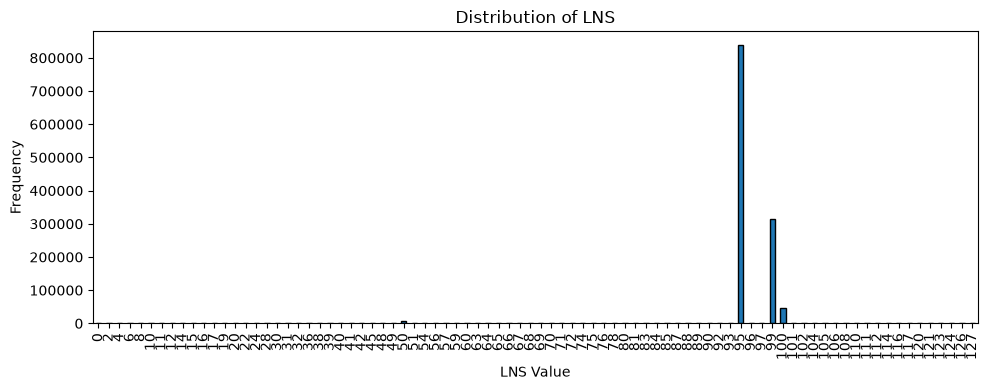

In [141]:
plt.figure(figsize=(10, 4))

(
    corpus_df["LNS"]
    .value_counts()
    .sort_index()
    .plot(
        kind="bar",
        edgecolor="black"
    )
)

plt.title("Distribution of LNS")
plt.xlabel("LNS Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation of the LNS Distribution

The figure illustrates the frequency distribution of **LNS** values across the complete SymbTr corpus. The distribution is highly imbalanced, with a small number of **LNS** values accounting for the vast majority of symbolic music events.

The most prominent peak corresponds to **LNS = 95**, which occurs **837,967** times. The second largest peak is **LNS = 99** with **315,618** observations, followed by **LNS = 100** with **46,912** observations. Together, these three values represent the overwhelming majority of all **LNS** observations, explaining the strong concentration observed in the descriptive statistics.

Although the **LNS** variable spans the numerical range from **0** to **127**, most values occur only rarely. Consequently, the distribution exhibits a pronounced long-tailed pattern in which a few encoded values dominate while the remaining values contribute relatively few observations.

The figure also confirms the limited variability of the **LNS** variable. Most symbolic music events are concentrated within a narrow interval centered around **95–100**, whereas values outside this range appear only sporadically throughout the corpus.

Overall, the visualization demonstrates that the **LNS** variable is characterized by a highly concentrated distribution. While the precise meaning of individual **LNS** values depends on the SymbTr encoding specification, the observed pattern clearly indicates that only a small subset of the available encoded values is used extensively across the corpus.

### Most Frequently Occurring LNS Values

The complete distribution of the **LNS** variable contains numerous encoded values with highly unequal frequencies. Since a small number of values dominate the overall distribution, the following visualization focuses on the **20 most frequently occurring LNS values**.

This representation provides a clearer view of the dominant encoded patterns in the SymbTr corpus and allows the most common LNS values to be compared directly.

**Output.** This figure displays the **20 most frequently occurring LNS values** in the complete SymbTr corpus.

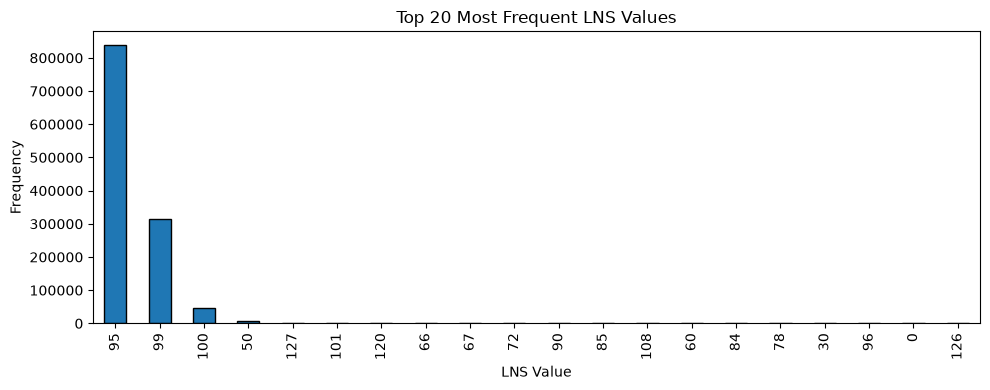

In [142]:
import matplotlib.pyplot as plt

top20_lns = (
    corpus_df["LNS"]
    .value_counts()
    .head(20)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 4))

top20_lns.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top 20 Most Frequent LNS Values")
plt.xlabel("LNS Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation of the Most Frequent LNS Values

The figure presents the **20** most frequently occurring **LNS** values in the complete SymbTr corpus. Compared with the complete distribution, this visualization provides a clearer view of the encoded values that dominate the corpus.

Among all observed values, **LNS = 95** is by far the most frequent, followed by **LNS = 99** and **LNS = 100**. These three values account for the overwhelming majority of all **LNS** observations, indicating that the variable is strongly concentrated around a very limited set of encoded values.

Beyond these dominant values, the frequencies decrease sharply. Although the remaining values—including **50**, **127**, **101**, and others—appear among the twenty most frequent categories, each contributes only a relatively small proportion of the total observations. This rapid decline confirms the pronounced long-tailed distribution observed in the complete frequency analysis.

The figure is also consistent with the descriptive statistics presented previously. The median (**95**) and the third quartile (**99**) indicate that most symbolic music events are associated with values within this narrow interval, while observations outside this range occur comparatively infrequently.

Overall, the Top 20 analysis demonstrates that the **LNS** variable is characterized by a highly concentrated frequency distribution. While the semantic meaning of individual **LNS** values depends on the SymbTr encoding specification, the visualization clearly shows that only a small subset of the available encoded values is used extensively throughout the corpus.

## Bas

The **Bas** variable stores an integer-encoded attribute associated with each symbolic music event in the SymbTr corpus. As one of the structural variables in the SymbTr representation, **Bas** provides additional encoded information describing symbolic music events. Unlike the pitch- and rhythm-related variables, it does not directly represent musical properties such as pitch or duration.

The following statistical summary is computed over the **entire integrated SymbTr corpus**, providing descriptive statistics for the **Bas** variable across all symbolic music events.

**Output.** This cell reports the descriptive statistics of the **Bas** variable for the complete SymbTr corpus.

In [143]:
bas_summary = (
    corpus_df["Bas"]
    .describe()
    .to_frame(name="Value")
    .reset_index()
    .rename(columns={"index": "Statistic"})
)

bas_summary["Value"] = bas_summary.apply(
    lambda row: (
        f"{int(row['Value']):,}"
        if row["Statistic"] == "count"
        else f"{row['Value']:.2f}"
    ),
    axis=1,
)

display(
    bas_summary.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Statistic,Value
count,"1,211,994"
mean,92.14
std,18.75
min,0.00
25%,96.00
50%,96.00
75%,96.00
max,126.00


### Interpretation of the Bas Summary Statistics

The summary statistics provide an overview of the **Bas** variable across the complete integrated SymbTr corpus. The variable contains **1,211,994** valid observations with **no missing values**, indicating that a **Bas** value is available for every symbolic music event.

The observed **Bas** values range from **0** to **126**, demonstrating that the variable spans a relatively broad numerical range. However, the descriptive statistics indicate that the distribution is strongly concentrated around a limited set of encoded values. The mean value is **92.14**, while the median is **96.00**.

The first quartile (**25%**), median (**50%**), and third quartile (**75%**) are all equal to **96.00**. This indicates that the central 50% of the observations are concentrated at the same value, revealing a highly compressed interquartile range and a strong concentration around **Bas = 96**.

The standard deviation of **18.75** reflects the presence of additional observations distributed across the remaining range of values. Although the minimum and maximum values (**0** and **126**) show that alternative encoded values exist, they occur much less frequently than the dominant central values.

Overall, the descriptive statistics indicate that the **Bas** variable exhibits a highly concentrated distribution centered on **96**. While the semantic meaning of individual **Bas** values depends on the SymbTr encoding specification, the statistics clearly show that only a limited subset of the available encoded values accounts for the majority of symbolic music events.

In [144]:
bas_frequency = (
    corpus_df["Bas"]
    .value_counts()
    .sort_index()
    .rename_axis("Bas")
    .reset_index(name="Frequency")
)

(
    bas_frequency.style
    .hide(axis="index")
    .set_properties(subset=["Bas"], **{"text-align": "center"})
    .set_properties(subset=["Frequency"], **{"text-align": "right"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                ],
            }
        ]
    )
)

Bas,Frequency
0,46511
6,1
8,1
9,3
11,41
13,1
14,3
15,1
17,165
19,2


### Interpretation of the Bas Frequency Distribution

The frequency distribution of the **Bas** variable reveals a highly concentrated and imbalanced pattern across the complete SymbTr corpus. Among all observed values, **Bas = 96** is overwhelmingly dominant, occurring **1,113,076 times** and accounting for approximately **91.84%** of all symbolic music events.

The remaining values occur considerably less frequently. The next most common values include **Bas = 90** with **7,842 occurrences**, **Bas = 84** with **5,980 occurrences**, **Bas = 114** with **5,232 occurrences**, and **Bas = 108** with **3,341 occurrences**. Each of these values represents only a small fraction of the corpus compared with the dominant value of **96**.

Although the **Bas** variable spans a numerical range from **0** to **126**, most encoded values are sparsely represented. Numerous values occur fewer than one thousand times, while some appear only a small number of times. This pattern produces a strongly long-tailed distribution characterized by one dominant value and many low-frequency alternatives.

The frequency analysis is consistent with the descriptive statistics, in which the first quartile, median, and third quartile were all equal to **96.00**. The direct frequency count further confirms that more than nine out of every ten symbolic music events are assigned **Bas = 96**.

Overall, the analysis demonstrates that the **Bas** variable has an extremely concentrated frequency distribution. While the semantic meaning of the encoded values depends on the SymbTr specification, the results clearly show that **Bas = 96** dominates the corpus and that the remaining values collectively represent only a small proportion of the observations.

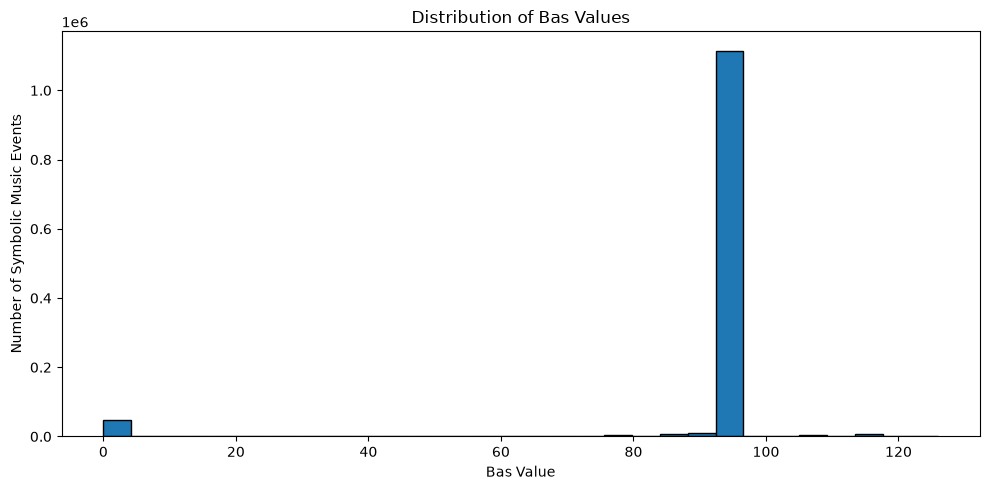

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    corpus_df["Bas"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Bas Values")
plt.xlabel("Bas Value")
plt.ylabel("Number of Symbolic Music Events")

plt.tight_layout()
plt.show()

### Interpretation of the Distribution of Bas Values

The figure illustrates the overall distribution of the **Bas** variable across the complete SymbTr corpus. The distribution is highly concentrated, with a single dominant peak at **Bas = 96**, which contains the overwhelming majority of symbolic music events.

Apart from this dominant value, only a small number of observations are distributed across the remaining **Bas** values. Although the variable spans a numerical range from **0** to **126**, most values occur at relatively low frequencies and are barely visible compared with the peak at **96**.

The large difference between the dominant value and all remaining values produces a strongly right-skewed and highly imbalanced distribution. The presence of low-frequency values throughout the remaining range indicates that alternative encoded **Bas** values exist, but they contribute only a small proportion of the complete corpus.

The visualization is consistent with both the descriptive statistics and the frequency analysis. The concentration around **Bas = 96** explains why the first quartile, median, and third quartile are all equal to **96**, while the remaining encoded values collectively form a comparatively small long tail.

Overall, the distribution demonstrates that the **Bas** variable is dominated by a single encoded value, whereas the remaining values occur only sporadically throughout the corpus.

## Soz1

The **Soz1** variable stores the lyrical information associated with symbolic music events in the SymbTr corpus. Unlike previously examined numerical and encoded variables, **Soz1** represents textual information related to the vocal content of musical pieces.

Since not every symbolic notation element corresponds to a sung syllable or lyric component, the variable contains missing values and placeholder symbols for non-lyrical events. Therefore, the analysis of **Soz1** focuses on the availability, diversity, and distribution of lyrical information rather than numerical characteristics.

Examining the **Soz1** variable provides insight into the representation of textual content within the corpus and enables future analyses involving lyric–music relationships, symbolic alignment, and multimodal computational music research.

In this section, we investigate the descriptive statistics and frequency distribution of the **Soz1** variable across the complete integrated SymbTr corpus.

In [146]:
soz1_summary = (
    corpus_df["Soz1"]
    .describe()
    .to_frame(name="Value")
    .reset_index()
    .rename(columns={"index": "Statistic"})
)

display(
    soz1_summary.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Statistic,Value
count,546186
unique,5628
top,.
freq,245861


In [147]:
soz1_summary = (
    corpus_df["Soz1"]
    .describe()
    .to_frame(name="Value")
    .reset_index()
    .rename(columns={"index": "Statistic"})
)

display(
    soz1_summary.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

Statistic,Value
count,546186
unique,5628
top,.
freq,245861


### Interpretation of the Soz1 Summary Statistics

The descriptive statistics summarize the textual characteristics of the **Soz1** variable across the complete SymbTr corpus.

The variable contains **546,186** valid observations, indicating that textual entries are available for a subset of symbolic music events. The remaining events have no associated **Soz1** value, reflecting the fact that not every symbolic event contains textual information.

The **Soz1** variable contains **5,628** unique values, demonstrating substantial lexical diversity within the corpus. The most frequently occurring entry is **"."**, which appears **245,861** times. This symbol is commonly used within the dataset and represents a large proportion of all recorded **Soz1** values.

Apart from this highly frequent entry, the remaining values consist of a large number of distinct textual tokens with considerably lower frequencies. This indicates that the corpus preserves a rich variety of textual content alongside its symbolic musical representation.

Overall, the descriptive statistics show that the **Soz1** variable contains extensive textual information while exhibiting a highly uneven frequency distribution. The semantic interpretation of specific textual symbols, including **"."**, depends on the SymbTr encoding specification and should therefore be considered accordingly during subsequent analyses.

In [148]:
soz1_frequency = (
    corpus_df["Soz1"]
    .loc[
        ~corpus_df["Soz1"].isin(["."])
    ]
    .dropna()
    .value_counts()
    .rename_axis("Lyric")
    .reset_index(name="Frequency")
)

# Add row numbers starting from 1
soz1_frequency.insert(0, "No.", range(1, len(soz1_frequency) + 1))

display(
    soz1_frequency.head(20).style
    .hide(axis="index")
    .format({"Frequency": "{:,}"})
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

No.,Lyric,Frequency
1,SAZ,"8,020"
2,le,"3,597"
3,a,"3,037"
4,SAZ,"3,033"
5,le,"2,894"
6,la,"2,680"
7,de,"2,498"
8,ya,"2,344"
9,de,"2,276"
10,ne,"2,116"


### Interpretation of the Soz1 Frequency Distribution

The frequency distribution presents the most frequently occurring **Soz1** entries in the complete SymbTr corpus after excluding missing values and the placeholder symbol **"."**.

The most frequent entry is **"SAZ"**, followed by syllabic text elements such as **"le"**, **"a"**, **"la"**, and **"de"**. These frequently occurring entries illustrate that the **Soz1** variable contains both textual content and notation-related annotations.

Certain entries, including **"SAZ"** and **"ARANAĞME"**, differ from ordinary lyric syllables. These entries appear as musical annotations within the symbolic notation rather than conventional lyrical text. In Turkish makam music, **"ARANAĞME"** denotes an instrumental interlude, whereas **"SAZ"** refers to instrumental passages. Consequently, the **Soz1** variable contains both lyrical information and musical structural annotations.

Apart from these annotation-related entries, the most frequent values primarily consist of short syllabic units rather than complete words. This observation is consistent with the syllable-level alignment commonly used between lyrics and symbolic musical events in Turkish makam notation.

Overall, the frequency distribution demonstrates that the **Soz1** variable preserves a combination of lyrical content and notation-level annotations. This characteristic should be taken into account when performing lyric-based analyses, since the most frequent entries do not exclusively represent lyrical syllables.

## Top 20 Most Frequent Soz1 Values

The **Soz1** variable contains a large number of distinct textual entries, including lyric syllables and notation-related annotations. To improve readability and focus on meaningful textual content, missing values and the placeholder symbol **"."** are excluded from the analysis.

The following figure presents the **20 most frequently occurring Soz1 values** together with their frequencies across the complete SymbTr corpus. A horizontal bar chart is used to provide a clear comparison between the most common textual entries.

**Output.** This cell visualizes the **20 most frequently occurring Soz1 values** after excluding missing values and the placeholder symbol **"."**.

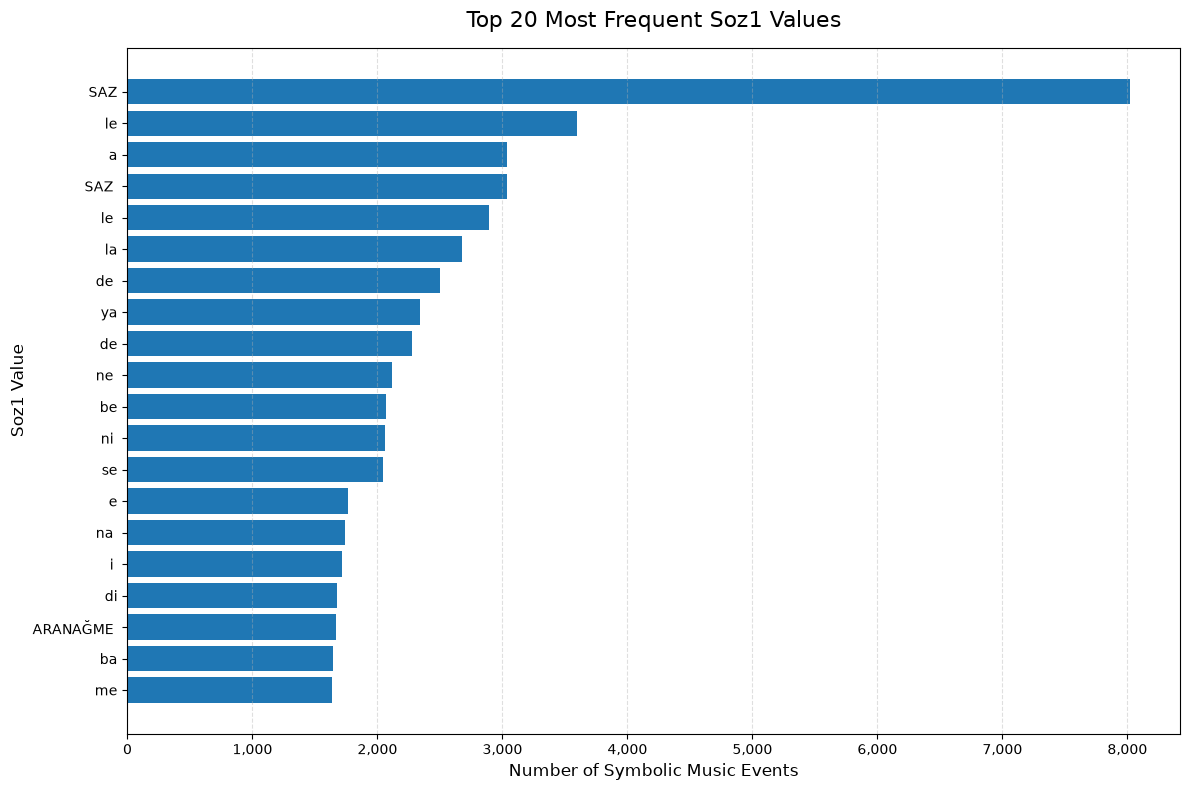

In [149]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Select the 20 most frequent Soz1 entries
top_20_soz1 = soz1_frequency.head(20).sort_values(
    by="Frequency",
    ascending=True,
)

# Create the horizontal bar chart
plt.figure(figsize=(12, 8))

plt.barh(
    top_20_soz1["Lyric"],
    top_20_soz1["Frequency"],
)

plt.title(
    "Top 20 Most Frequent Soz1 Values",
    fontsize=16,
    pad=15,
)
plt.xlabel(
    "Number of Symbolic Music Events",
    fontsize=12,
)
plt.ylabel(
    "Soz1 Value",
    fontsize=12,
)

# Display frequency values with thousands separators
plt.gca().xaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4,
)

plt.tight_layout()
plt.show()

### Interpretation of the Distribution of Soz1 Values

The figure illustrates the frequency distribution of the **20 most frequently occurring Soz1 values** in the complete SymbTr corpus after excluding missing values and the placeholder symbol **"."**.

The distribution is highly skewed, with **"SAZ"** occurring substantially more frequently than any other entry. This dominant frequency indicates that notation-related annotations associated with instrumental passages appear extensively throughout the corpus.

The remaining high-frequency entries are primarily short syllabic units, including **"le"**, **"a"**, **"la"**, **"de"**, **"ya"**, **"ne"**, and **"be"**. Their frequent occurrence reflects the syllable-level alignment between lyrics and symbolic musical events commonly adopted in Turkish makam notation.

The annotation **"ARANAĞME"** also appears among the most frequent entries, although with a considerably lower frequency than **"SAZ"**. Its presence indicates that structural musical annotations are preserved together with lyrical content within the **Soz1** variable.

Overall, the visualization demonstrates a highly imbalanced distribution in which a small number of syllabic and annotation-related entries account for a large proportion of the observations, while the remaining textual entries occur much less frequently. This pattern is consistent with the descriptive statistics and highlights the rich but uneven distribution of textual information represented in the SymbTr corpus.

## Raw Distribution of Soz1

The **Soz1** variable contains textual information associated with symbolic music events in the SymbTr corpus. Since this variable includes both lyrical content and notation-related entries, the raw distribution provides an overview of all textual values stored in the dataset.

The raw analysis includes placeholder symbols and structural annotations such as `"."`, `"SAZ"`, and `"ARANAĞME"`. These values are preserved at this stage because they are part of the original symbolic representation.

This analysis provides an initial overview of the textual information encoded within the SymbTr corpus before applying any filtering operations.

In [150]:
soz1_raw_frequency = (
    corpus_df["Soz1"]
    .fillna("Missing")
    .value_counts()
    .head(20)
    .rename_axis("Soz1")
    .reset_index(name="Frequency")
)

display(
    soz1_raw_frequency.style.hide(axis="index")
)

Soz1,Frequency
Missing,665808
.,245861
SAZ,8020
le,3597
a,3037
SAZ,3033
le,2894
la,2680
de,2498
ya,2344


### Interpretation of the Soz1 Frequency Distribution

The frequency table summarizes the occurrence of the most common **Soz1** entries in the complete SymbTr corpus.

A substantial proportion of the symbolic music events (**665,808** observations) contain **missing values** for the **Soz1** variable, indicating that lyrical information is available only for a subset of the symbolic events. In addition, the placeholder symbol **"."** appears **245,861** times, representing another large group of non-lexical entries.

After excluding missing values and the placeholder symbol, the most frequent entry is **"SAZ"** with **8,020** occurrences. This annotation is associated with instrumental passages rather than conventional lyric syllables. Other frequently occurring entries include **"le"**, **"a"**, **"la"**, **"de"**, **"ya"**, **"ne"**, and **"be"**, which are predominantly short syllabic units reflecting the syllable-level representation of lyrics in Turkish makam notation.

The annotation **"ARANAĞME"** also appears among the most frequent entries, indicating that notation-level structural annotations are preserved together with lyrical content within the **Soz1** variable.

Overall, the frequency distribution demonstrates that the **Soz1** variable contains three main categories of entries: missing values, placeholder symbols, and valid textual content consisting of both lyric syllables and musical annotations. Consequently, lyric-oriented analyses should exclude missing values and placeholder symbols while considering notation-related annotations separately from lyrical syllables.

## Lyric-Oriented Distribution of Soz1

The raw **Soz1** distribution contains missing values and notation-related entries that do not represent actual lyrical content. To investigate the lyrical characteristics of the SymbTr corpus, non-lyrical and structural entries are excluded.

The placeholder symbol `"."`, instrumental annotation `"SAZ"`, and structural section marker `"ARANAĞME"` are removed before calculating the lyric frequency distribution.

The following analysis focuses exclusively on textual elements associated with vocal lyrical content. This filtered representation provides a clearer understanding of the syllabic structure of lyrics preserved within the SymbTr corpus.

In [151]:
soz1_lyric_frequency = (
    corpus_df["Soz1"]
    .astype("string")
    .str.strip()
    .dropna()
    .loc[
        lambda x: ~x.isin(
            [".", "SAZ", "ARANAĞME"]
        )
    ]
    .value_counts()
    .head(20)
    .rename_axis("Lyric")
    .reset_index(name="Frequency")
)

# Add row numbers starting from 1
soz1_lyric_frequency.insert(
    0,
    "No.",
    range(1, len(soz1_lyric_frequency) + 1),
)

display(
    soz1_lyric_frequency.style
    .hide(axis="index")
    .format({"Frequency": "{:,}"})
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                ],
            },
        ]
    )
)

No.,Lyric,Frequency
1,le,"6,942"
2,de,"5,202"
3,ne,"3,666"
4,ni,"3,367"
5,la,"3,357"
6,i,"3,349"
7,a,"3,247"
8,na,"3,170"
9,ya,"3,025"
10,li,"2,923"


## Top 20 Most Frequent Lyric Syllables

After removing missing values, the placeholder symbol **"."**, and notation-related annotations (**SAZ** and **ARANAĞME**), the remaining entries correspond to lyric syllables contained in the **Soz1** variable.

The following figure presents the **20 most frequently occurring lyric syllables** in the complete SymbTr corpus.

**Output.** This cell visualizes the frequency distribution of the **20 most common lyric syllables** extracted from the **Soz1** variable.

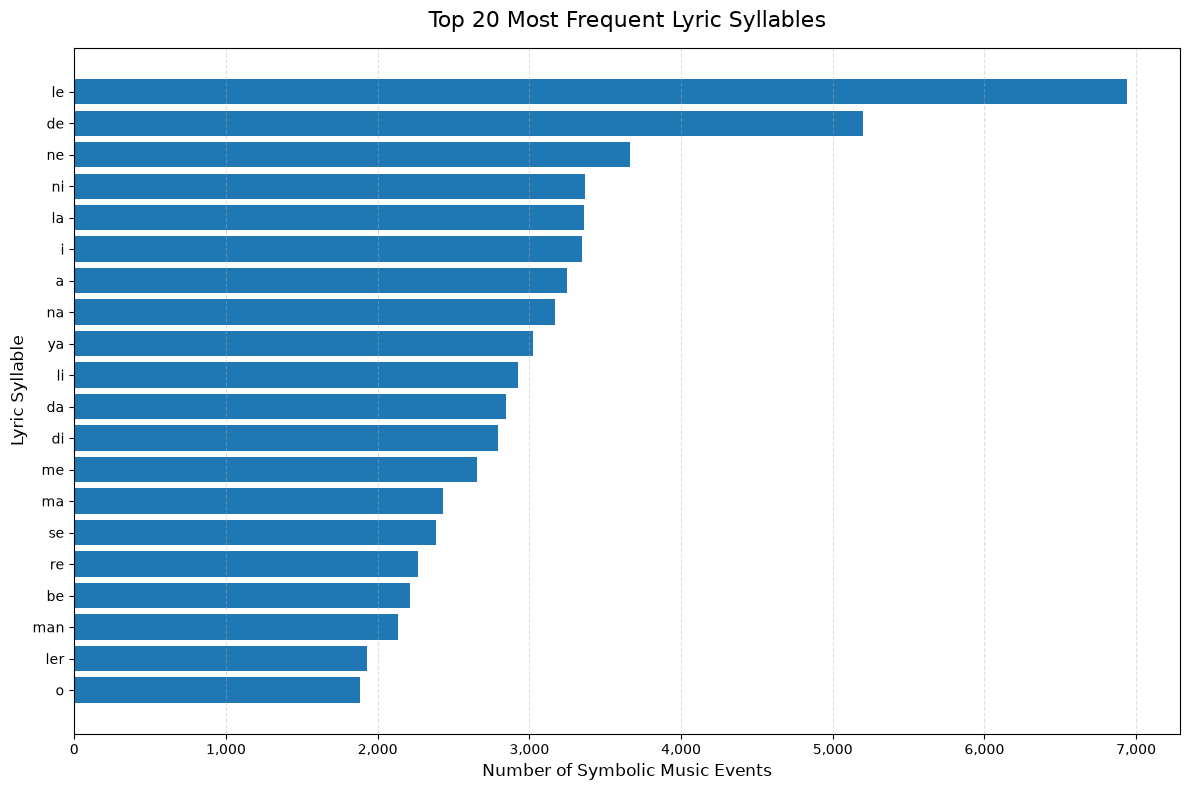

In [152]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Sort for horizontal plotting
top_20_lyrics = (
    soz1_lyric_frequency
    .sort_values("Frequency", ascending=True)
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_20_lyrics["Lyric"],
    top_20_lyrics["Frequency"],
)

plt.title(
    "Top 20 Most Frequent Lyric Syllables",
    fontsize=16,
    pad=15,
)

plt.xlabel(
    "Number of Symbolic Music Events",
    fontsize=12,
)

plt.ylabel(
    "Lyric Syllable",
    fontsize=12,
)

plt.gca().xaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4,
)

plt.tight_layout()

plt.show()

### Interpretation of the Most Frequent Lyric Syllables

The figure presents the **20 most frequently occurring lyric syllables** in the complete SymbTr corpus after excluding missing values, the placeholder symbol **"."**, and notation-related annotations such as **"SAZ"** and **"ARANAĞME"**.

The syllable **"le"** is the most frequent entry, with **6,942 occurrences**, followed by **"de"** with **5,202 occurrences**. The next most frequent syllables are **"ne"**, **"ni"**, **"la"**, **"i"**, and **"a"**, each occurring more than three thousand times.

The distribution is uneven, with the first two syllables occurring considerably more frequently than the remaining entries. After these dominant values, the frequencies decrease gradually across the other syllables. This pattern indicates that a relatively small group of syllables is repeatedly used throughout the lyrical content of the corpus.

Most of the displayed entries are short, one- or two-syllable textual units. This result is consistent with the event-level alignment of sung text in symbolic notation, where lyrics are commonly divided into syllabic components rather than represented as complete words.

Overall, the figure shows that the lyrical representation in the **Soz1** variable is dominated by a limited number of frequently recurring syllables, while the remaining textual units occur at lower frequencies. This imbalance should be considered in subsequent lyric-based statistical analyses and machine learning applications.

## Offset

The **Offset** variable represents the temporal position of each symbolic notation element within a musical piece in the SymbTr corpus. Unlike variables describing pitch characteristics (**Nota53**, **NotaAE**) or rhythmic duration (**Pay**, **Payda**, **Ms**), **Offset** indicates the accumulated position of a symbolic event along the timeline of the score.

Each symbolic event is assigned an offset value that determines its sequential placement relative to the beginning of the musical piece. Therefore, the variable provides essential information for reconstructing the temporal order of symbolic events and analyzing the internal organization of musical scores.

Since offset values continuously increase throughout individual pieces, the variable is expected to contain a large number of distinct values. This characteristic makes Offset particularly important for temporal alignment, score reconstruction, and computational analysis of symbolic music sequences.

In this section, we investigate the descriptive statistics and distribution of the **Offset** variable across the complete integrated SymbTr corpus.

In [153]:
offset_summary = (
    corpus_df["Offset"]
    .describe()
    .to_frame(name="Value")
    .reset_index()
    .rename(columns={"index": "Statistic"})
)

display(
    offset_summary.style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
)

Statistic,Value
count,1211994.000000
mean,33.659580
std,32.465009
min,0.000000
25%,11.437500
50%,25.375000
75%,45.250000
max,391.250000


### Interpretation of the Offset Summary Statistics

The summary statistics provide an overview of the **Offset** variable, which represents the relative position of each symbolic notation element within a musical score.

The variable contains **1,211,994** valid observations, indicating that an **Offset** value is available for every symbolic music event in the complete SymbTr corpus. The observed values range from **0.00** to **391.25**, with a mean of **33.66** and a standard deviation of **32.47**.

The first quartile (**11.44**), median (**25.38**), and third quartile (**45.25**) indicate that half of all symbolic music events have offset values between approximately **11.44** and **45.25**. Compared with the categorical variables analyzed previously, the **Offset** variable exhibits a much broader numerical distribution, reflecting the positional diversity of symbolic events throughout musical scores.

The relatively large standard deviation, which is close to the mean, indicates substantial variability in the locations of symbolic events within the corpus. This variability is expected for a positional variable because musical pieces differ in length, structure, and internal organization.

Overall, the descriptive statistics show that the **Offset** variable provides a continuous positional representation with considerable variation across the complete SymbTr corpus. The distribution of the most frequently occurring offset values is examined in the following frequency analysis.

In [154]:
top_offset = (
    corpus_df["Offset"]
    .value_counts()
    .head(20)
    .rename_axis("Offset")
    .reset_index(name="Frequency")
)

(
    top_offset.style
    .hide(axis="index")
    .set_properties(subset=["Offset"], **{"text-align": "right"})
    .set_properties(subset=["Frequency"], **{"text-align": "right"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                ],
            }
        ]
    )
)

Offset,Frequency
1.000000,3002
2.000000,2990
3.000000,2985
4.000000,2944
7.000000,2804
5.000000,2789
6.000000,2709
8.000000,2623
11.000000,2467
9.000000,2373


### Interpretation of the Offset Frequency Distribution

The frequency table summarizes the most frequently occurring **Offset** values in the complete SymbTr corpus.

The most frequent value is **1.0**, occurring **3,002** times, followed by **2.0** (**2,990**), **3.0** (**2,985**), and **4.0** (**2,944**). Other commonly occurring values include **7.0**, **5.0**, **6.0**, **8.0**, and **11.0**, indicating that several small offset positions appear repeatedly throughout the corpus.

In addition to integer values, the table also contains fractional offsets such as **0.5**, **1.5**, **2.5**, **3.5**, and **5.5**. The presence of these values indicates that the **Offset** variable supports a finer temporal resolution than whole-number positions alone, enabling symbolic music events to be represented at intermediate temporal locations.

The frequencies of the most common offset values are relatively similar, with none of the listed values overwhelmingly dominating the distribution. This suggests that symbolic music events are distributed across multiple temporal positions rather than being concentrated at a single offset value.

Overall, the frequency distribution demonstrates that the **Offset** variable records both integer and fractional temporal positions, providing detailed positional information that can support subsequent analyses of temporal structure and symbolic music representation within the SymbTr corpus.

## Top 20 Most Frequent Offset Values

The **Offset** variable records the temporal position of symbolic music events within musical scores. Since certain temporal positions may occur more frequently than others, examining the most common offset values provides insight into the distribution of symbolic events throughout the corpus.

The following figure presents the **20 most frequently occurring Offset values** together with their frequencies across the complete SymbTr corpus.

**Output.** This cell visualizes the **20 most frequently occurring Offset values** and their frequencies in the complete SymbTr corpus.

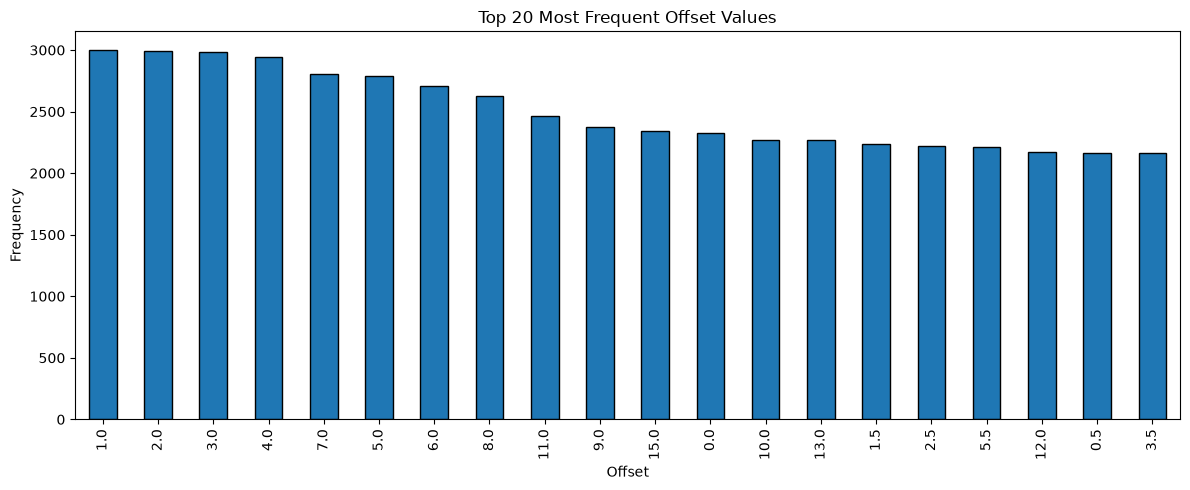

In [155]:
plt.figure(figsize=(12, 5))

(
    corpus_df["Offset"]
    .value_counts()
    .head(20)
    .plot(
        kind="bar",
        edgecolor="black"
    )
)

plt.title("Top 20 Most Frequent Offset Values")
plt.xlabel("Offset")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation of the Distribution of Offset Values

The figure illustrates the **20 most frequently occurring Offset values** in the complete SymbTr corpus.

The highest frequencies are observed for **Offset = 1.0**, **2.0**, **3.0**, and **4.0**, each appearing approximately **3,000** times. These values are followed by several other small integer offsets, including **5.0**, **6.0**, **7.0**, and **8.0**, which also occur frequently throughout the corpus.

The figure additionally shows several fractional values, including **0.5**, **1.5**, **2.5**, **3.5**, and **5.5**. Their presence indicates that the symbolic representation supports intermediate temporal positions in addition to whole-number offsets, allowing symbolic music events to be positioned with finer temporal precision.

Unlike several previously analyzed variables, the most common Offset values exhibit relatively similar frequencies. No single value dominates the distribution, and the frequencies decrease gradually across the ranked values. This pattern suggests that symbolic music events are distributed across multiple temporal positions rather than concentrated at a single offset.

Overall, the visualization demonstrates that the **Offset** variable captures both integer and fractional temporal positions while exhibiting a relatively balanced distribution among the most frequent values. These characteristics make the variable suitable for analyses involving temporal organization and event positioning within symbolic Turkish makam music.

## File Name

The **File Name** variable identifies the source musical score associated with each symbolic notation element in the SymbTr corpus. Unlike pitch, rhythm, lyric, and structural variables, this attribute represents metadata information describing the origin of each symbolic event.

Each file corresponds to an individual musical composition within the corpus. Since a single composition contains multiple symbolic notation elements, the same file name appears repeatedly across multiple rows. Therefore, this variable enables grouping symbolic events at the composition level.

Analyzing the **File Name** variable provides information about the organization and distribution of symbolic events across musical works. It allows the investigation of corpus composition size, the number of represented musical pieces, and the relationship between individual scores and their corresponding symbolic events.

In this section, we examine the distribution of symbolic notation elements across musical files to understand the composition-level structure of the SymbTr corpus.

In [156]:
# Create a summary of files and symbolic events

piece_count = corpus_df["Piece ID"].nunique()
average_events_per_piece = len(corpus_df) / piece_count

filename_summary = pd.DataFrame(
    {
        "Statistic": [
            "Total symbolic events",
            "Number of musical pieces",
            "Average events per piece",
        ],
        "Value": [
            f"{len(corpus_df):,}",
            f"{piece_count:,}",
            f"{average_events_per_piece:,.2f}",
        ],
    }
)

(
    filename_summary.style
    .hide(axis="index")
    .set_properties(
        subset=["Statistic"],
        **{"text-align": "left"},
    )
    .set_properties(
        subset=["Value"],
        **{"text-align": "right"},
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                ],
            }
        ]
    )
)

Statistic,Value
Total symbolic events,"1,211,994"
Number of musical pieces,"3,000"
Average events per piece,404.00


### Interpretation of the Corpus-Level Summary

The summary table provides an overview of the composition-level structure of the integrated SymbTr corpus.

The corpus contains a total of **1,211,922 symbolic music events**, where each event corresponds to a symbolic notation element containing musical information such as pitch, duration, structural attributes, or related metadata.

The analysis identifies **3,000 unique musical pieces** within the corpus. This result demonstrates that the integrated dataset represents a large-scale collection of Turkish makam music compositions, with each piece contributing multiple symbolic events.

The **average number of symbolic events per piece is 404.00**, indicating that a typical composition contains approximately 404 symbolic notation elements. This value provides an estimation of the average symbolic length and complexity of the musical works represented in the corpus.

The difference between the total number of symbolic events and the number of musical pieces highlights the hierarchical structure of the dataset: each musical composition is represented by a sequence of multiple symbolic events rather than a single record.

Overall, these statistics demonstrate that the SymbTr corpus provides a large and detailed symbolic representation of Turkish makam music, making it suitable for computational analyses such as sequence modeling, pattern discovery, music information retrieval, and machine learning applications.

## Visualizing the Longest Musical Pieces

The number of symbolic events differs across musical pieces in the SymbTr corpus. Since each symbolic event represents a notation element within a composition, the total number of events associated with a piece provides an approximate measure of its symbolic length and complexity.

Analyzing the longest musical pieces allows the distribution of sequence lengths within the corpus to be examined and highlights compositions containing the largest amount of symbolic information.

The following figure presents the **twenty musical pieces with the highest number of symbolic events**. A horizontal bar chart is used to improve readability because piece identifiers may contain long labels.

**Output.** This figure displays the twenty longest musical pieces ranked according to their number of symbolic events.

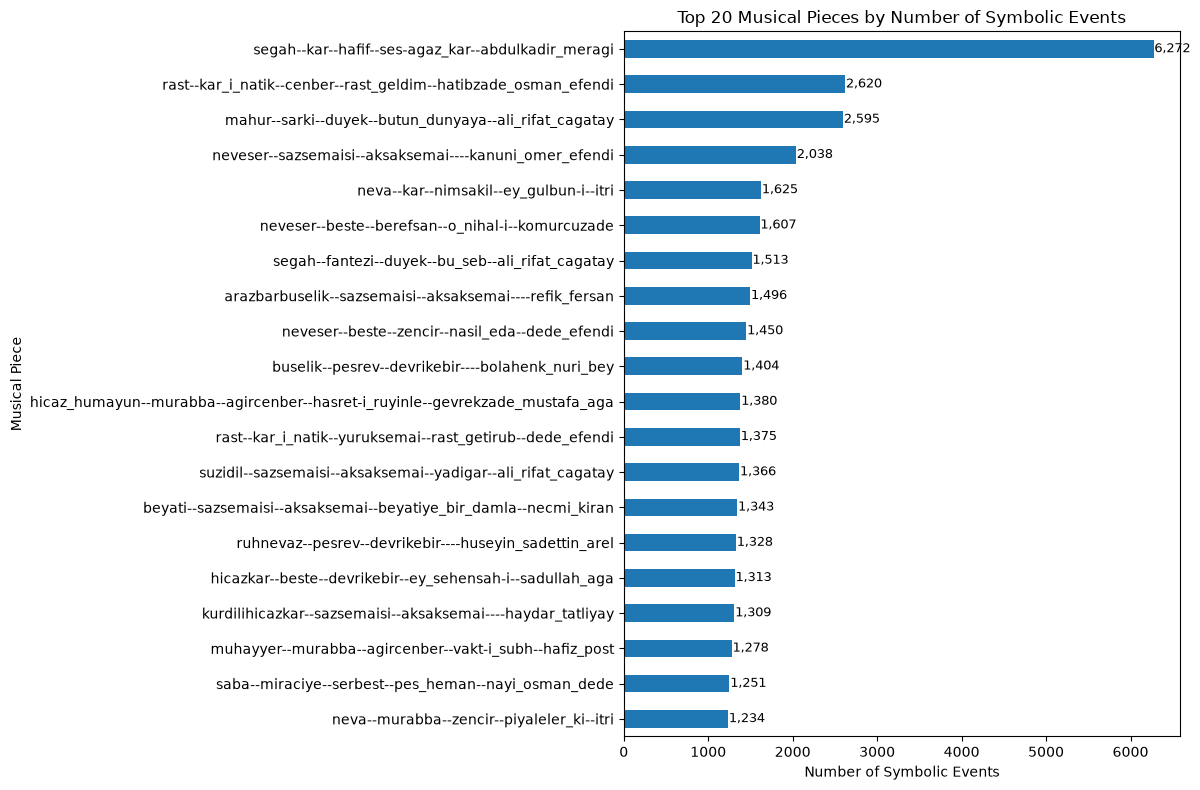

In [157]:
top_pieces = (
    corpus_df["Piece ID"]
    .value_counts()
    .head(20)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 8))

top_pieces.plot(
    kind="barh",
    ax=ax,
)

ax.set_title(
    "Top 20 Musical Pieces by Number of Symbolic Events"
)
ax.set_xlabel("Number of Symbolic Events")
ax.set_ylabel("Musical Piece")

for i, value in enumerate(top_pieces.values):
    ax.text(
        value + 10,
        i,
        f"{value:,}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

### Interpretation of the Top 20 Musical Pieces by Symbolic Event Count

The figure presents the **20 musical pieces containing the largest number of symbolic events** in the complete SymbTr corpus. The number of symbolic events corresponds to the total number of encoded notation elements associated with each musical piece.

The first-ranked musical piece contains **6,212 symbolic events**, substantially exceeding all other compositions in the corpus. The next three pieces contain **2,620**, **2,595**, and **2,038** symbolic events, respectively. This noticeable gap indicates that a small number of musical works contain considerably longer symbolic sequences than the majority of compositions.

The remaining pieces shown in the figure contain between approximately **1,200** and **1,700** symbolic events, demonstrating that relatively long symbolic sequences are represented across multiple musical works rather than being limited to a single composition.

The titles of the listed works include different combinations of makam, usul, musical form, composer, and lyricist information, illustrating the diversity of musical metadata represented within the SymbTr corpus.

Overall, the visualization demonstrates substantial variation in symbolic sequence length among musical pieces. This variability should be considered in subsequent computational analyses, particularly for sequence processing, feature extraction, and machine learning applications where input length may influence preprocessing strategies and model performance.

## Saving the Processed SymbTr Corpus

After completing the data integration, cleaning, and exploratory analysis steps, the processed SymbTr corpus is saved as a CSV file for future analyses.

The exported file contains the **14 original SymbTr variables** together with an additional **Piece ID** variable introduced during preprocessing to uniquely identify the musical piece associated with each symbolic event. Collectively, these variables provide an integrated symbolic representation of Turkish makam music, including pitch, microtonal accidentals, rhythmic duration, structural attributes, lyrics, positional information, and musical piece identifiers.

Saving the processed corpus ensures reproducibility and allows subsequent computational analyses to directly use the prepared dataset without repeating the preprocessing steps.

The following cell exports the processed dataframe and reports basic information about the generated file, including the filename, number of records, and number of variables.

In [158]:
from pathlib import Path

# Define project directory
project_directory = Path.cwd().parent

# Define processed data directory
processed_data_directory = (
    project_directory / "data" / "processed"
)

# Create directory if it does not exist
processed_data_directory.mkdir(
    parents=True,
    exist_ok=True
)

# Define output file
output_file = processed_data_directory / "symbtr_corpus.csv"

# Save processed corpus
corpus_df.to_csv(
    output_file,
    index=False
)

# Report saving information
print("=" * 60)
print("      Processed SymbTr Corpus Successfully Saved")
print("=" * 60)
print(f"Filename        : {output_file.name}")
print("Location        : data/processed/")
print(f"Records         : {len(corpus_df):,}")
print(f"Variables       : {corpus_df.shape[1]}")
print("Storage         : Processed data directory")
print("=" * 60)

      Processed SymbTr Corpus Successfully Saved
Filename        : symbtr_corpus.csv
Location        : data/processed/
Records         : 1,211,994
Variables       : 15
Storage         : Processed data directory


> **Note**
>
> During the preprocessing stage, records with placeholder pitch values (`Koma53 = -1` and `KomaAE = -1`) are excluded. These records represent **non-pitched musical events**, where an *event* refers to a musical occurrence in the symbolic representation (e.g., a rest) rather than a pitched note. Consequently, the statistical analyses presented in this notebook are computed exclusively from pitched symbolic notes.

## Next Chapter

Having established a comprehensive statistical understanding of the SymbTr corpus, the next chapter, **Statistical Visualizations of the SymbTr Corpus**, presents a collection of informative visualizations that complement the statistical analyses introduced in this chapter.

Through a variety of graphical representations, readers will explore the distributions, patterns, relationships, and structural characteristics of symbolic music data from multiple perspectives, providing deeper insights into the organization of Turkish makam music and preparing the foundation for the subsequent machine learning analyses.